In [21]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("HF_TOKEN")

# **Prepare Data**

In [ ]:
pip install tabpfn

In [ ]:
from huggingface_hub import login
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
import zipfile
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from tabpfn import TabPFNClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import fbeta_score, classification_report
warnings.filterwarnings("ignore")

In [ ]:
login(token=secret_value_0)

In [23]:
train_df = pd.read_csv("/home/drasogun/DraSoGun/AI/SuperAI_ss6/Competitions/Heart-Disease-Prediction/super-ai-engineer-ss-6-heart-disease-prediction/train.csv")
test_df = pd.read_csv("/home/drasogun/DraSoGun/AI/SuperAI_ss6/Competitions/Heart-Disease-Prediction/super-ai-engineer-ss-6-heart-disease-prediction/test.csv")

# **Exploratory Data Analysis**

## Data

In [24]:
train_df.isna()

,ID,History of HeartDisease or Attack,High Blood Pressure,Told High Cholesterol,Cholesterol Checked,Body Mass Index,Smoked 100+ Cigarettes,Diagnosed Stroke,Diagnosed Diabetes,Leisure Physical Activity,Heavy Alcohol Consumption,Health Care Coverage,Doctor Visit Cost Barrier,General Health,Difficulty Walking,Sex,Education Level,Income Level,Age,Vegetable or Fruit Intake (1+ per Day)
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
223079,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
223080,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
223081,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
223082,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [25]:
train_df.head()

,ID,History of HeartDisease or Attack,High Blood Pressure,Told High Cholesterol,Cholesterol Checked,Body Mass Index,Smoked 100+ Cigarettes,Diagnosed Stroke,Diagnosed Diabetes,Leisure Physical Activity,Heavy Alcohol Consumption,Health Care Coverage,Doctor Visit Cost Barrier,General Health,Difficulty Walking,Sex,Education Level,Income Level,Age,Vegetable or Fruit Intake (1+ per Day)
0,train_000001,No,Yes,Yes,Yes,40.68,Yes,No,No,No,No,Yes,No,Very Poor,Yes,Female,High school graduate,"$15,000 to less than $20,000",64,Yes
1,train_000002,No,No,No,No,24.36,Yes,No,No,Yes,No,No,Yes,Fair,No,Female,College graduate,"Less than $10,000",50,No
2,train_000003,No,Yes,Yes,Yes,27.33,No,No,No,No,No,Yes,Yes,Very Poor,Yes,Female,High school graduate,"$75,000 or more",61,Yes
3,train_000004,No,Yes,No,Yes,27.01,No,No,No,Yes,No,Yes,No,Good,No,Female,Some high school,"$35,000 to less than $50,000",74,Yes
4,train_000005,NaN,Yes,Yes,Yes,34.56,Yes,No,No,Yes,No,Yes,Yes,Very Poor,Yes,Male,Some high school,"$15,000 to less than $20,000",98,Yes


In [26]:
test_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 74361 entries, 0 to 74360
Data columns (total 19 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   ID                                      74361 non-null  str    
 1   High Blood Pressure                     74361 non-null  str    
 2   Told High Cholesterol                   74361 non-null  str    
 3   Cholesterol Checked                     74361 non-null  str    
 4   Body Mass Index                         74361 non-null  float64
 5   Smoked 100+ Cigarettes                  74361 non-null  str    
 6   Diagnosed Stroke                        74361 non-null  str    
 7   Diagnosed Diabetes                      74361 non-null  str    
 8   Leisure Physical Activity               74361 non-null  str    
 9   Heavy Alcohol Consumption               74361 non-null  str    
 10  Health Care Coverage                    74361 non-null  str    
 11  

## Statistic

In [27]:
train_df.describe()

,Body Mass Index,Age
count,211302.000000,223084.000000
mean,28.189817,54.739717
std,6.688447,17.795140
min,11.210000,18.000000
25%,23.880000,42.000000
50%,27.070000,56.000000
75%,31.100000,67.000000
max,98.630000,100.000000


In [40]:
test_df.describe()

,Age
count,74361.000000
mean,57.722112
std,16.449871
min,18.000000
25%,47.000000
50%,59.000000
75%,69.000000
max,100.000000


## Balance

<Axes: xlabel='History of HeartDisease or Attack', ylabel='count'>

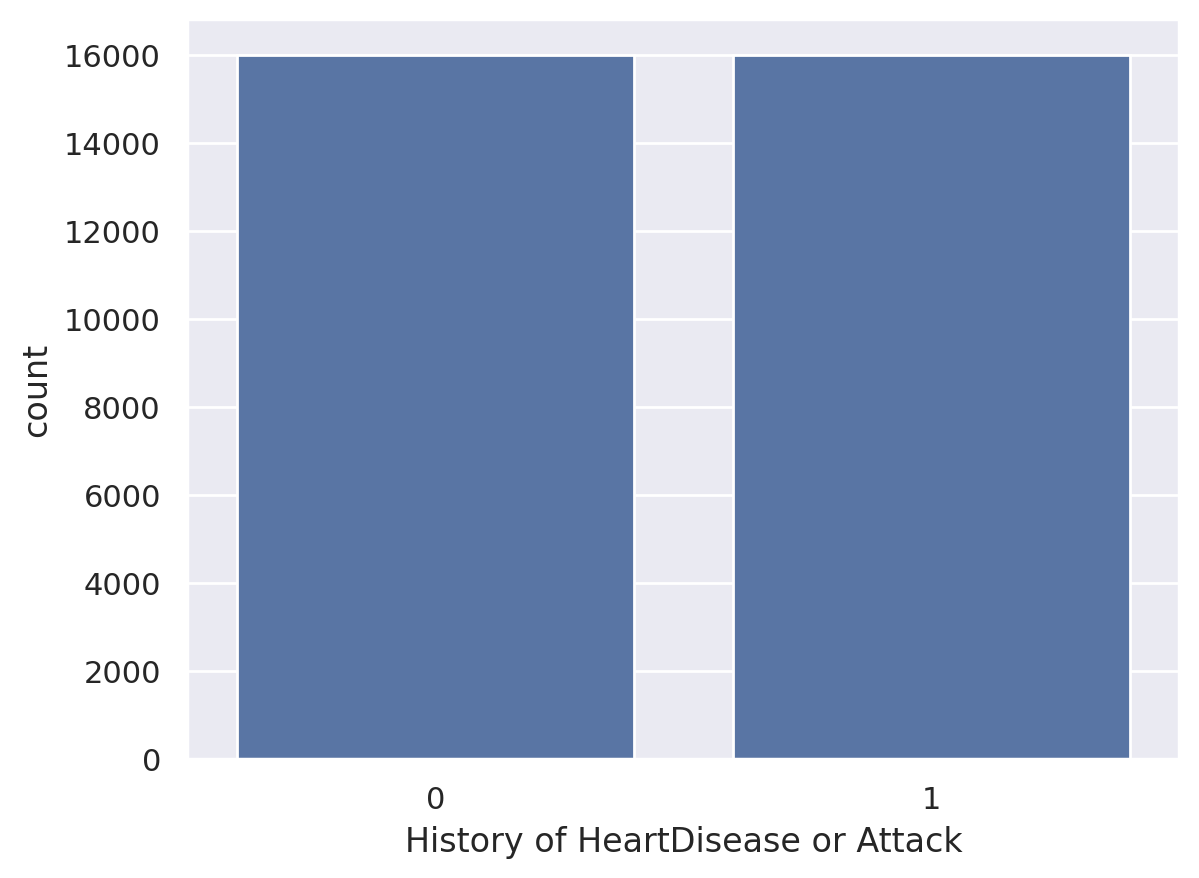

In [42]:
sns.countplot(data=train_df, x='History of HeartDisease or Attack')

## Duplicate

In [49]:
features = train_df.columns.values[2:21]
features

<ArrowStringArray>
[    'Told High Cholesterol',          'Diagnosed Stroke',
        'Diagnosed Diabetes', 'Heavy Alcohol Consumption',
            'General Health',        'Difficulty Walking',
              'Income Level',                       'Age']
Length: 8, dtype: str

In [50]:
train_dp = []
test_dp = []
for i in features:
    f = train_df[i].value_counts()
    train_dp.append([i,f.max(),f.idxmax()])
    f = test_df[i].value_counts()
    test_dp.append([i,f.max(),f.idxmax()])
train_dp = pd.DataFrame(train_dp,columns=["Feature","Dup","Value"])
test_dp = pd.DataFrame(test_dp,columns=["Feature","Dup","Value"])

In [51]:
train_dp

,Feature,Dup,Value
0,Told High Cholesterol,17553,1
1,Diagnosed Stroke,28881,0
2,Diagnosed Diabetes,24541,0
3,Heavy Alcohol Consumption,30537,0
4,General Health,9995,0
5,Difficulty Walking,23084,0
6,Income Level,8939,8
7,Age,1003,65


In [52]:
test_dp

,Feature,Dup,Value
0,Told High Cholesterol,42685,0
1,Diagnosed Stroke,71348,0
2,Diagnosed Diabetes,63521,0
3,Heavy Alcohol Consumption,70193,0
4,General Health,26087,1
5,Difficulty Walking,61881,0
6,Income Level,26614,8
7,Age,1991,61


# **Analysis Data**

## Preprocess

In [55]:
general_health = {'Excellent':2,'Good':1,'Fair':0,'Poor':-1,'Very Poor':-2}
income_level = {'$75,000 or more':8,'$50,000 to less than $75,000':7,'$35,000 to less than $50,000':6,'$25,000 to less than $35,000':5,'$20,000 to less than $25,000':4,'$15,000 to less than $20,000':3,'($10,000 to less than $15,000':2,'Less than $10,000':1}
yes_no = {'Yes':1,'No':0}
sex = {'Male':1,'Female':0}
yes_no_col_train = ['History of HeartDisease or Attack','High Blood Pressure','Told High Cholesterol','Cholesterol Checked','Smoked 100+ Cigarettes','Diagnosed Stroke','Diagnosed Diabetes',
             'Leisure Physical Activity','Heavy Alcohol Consumption','Doctor Visit Cost Barrier','Difficulty Walking','Vegetable or Fruit Intake (1+ per Day)','Health Care Coverage']
yes_no_col_test = ['High Blood Pressure','Told High Cholesterol','Cholesterol Checked','Smoked 100+ Cigarettes','Diagnosed Stroke','Diagnosed Diabetes',
             'Leisure Physical Activity','Heavy Alcohol Consumption','Doctor Visit Cost Barrier','Difficulty Walking','Vegetable or Fruit Intake (1+ per Day)','Health Care Coverage']
train_df[yes_no_col_train] = train_df[yes_no_col_train].replace(yes_no)
train_df['General Health'] = train_df['General Health'].replace(general_health)
train_df['Income Level'] = train_df['Income Level'].replace(income_level)
train_df['Sex'] = train_df['Sex'].replace(sex)
train_df.drop(['Education Level'], axis = 1,inplace = True)
train_df = train_df.dropna()
test_df[yes_no_col_test] = test_df[yes_no_col_test].replace(yes_no)
test_df['General Health'] = test_df['General Health'].replace(general_health)
test_df['Income Level'] = test_df['Income Level'].replace(income_level)
test_df['Sex'] = test_df['Sex'].replace(sex)
test_df.drop(['Education Level'], axis = 1,inplace = True)

KeyError: "['Cholesterol Checked', 'Smoked 100+ Cigarettes', 'Leisure Physical Activity', 'Doctor Visit Cost Barrier', 'Vegetable or Fruit Intake (1+ per Day)', 'Health Care Coverage'] not in index"

In [33]:
train_df.drop(['Sex'], axis = 1,inplace = True)
train_df.drop(['Body Mass Index'], axis = 1,inplace = True)
train_df.drop(['Leisure Physical Activity'], axis = 1,inplace = True)
train_df.drop(['Smoked 100+ Cigarettes'], axis = 1,inplace = True)
train_df.drop(['Health Care Coverage'], axis = 1,inplace = True)
train_df.drop(['Cholesterol Checked'], axis = 1,inplace = True)
train_df.drop(['Vegetable or Fruit Intake (1+ per Day)'], axis = 1,inplace = True)
train_df.drop(['Doctor Visit Cost Barrier'], axis = 1,inplace = True)
train_df.drop(['ID'], axis = 1,inplace = True)

In [ ]:
test_df.drop(['Sex'], axis = 1,inplace = True)
test_df.drop(['Body Mass Index'], axis = 1,inplace = True)
test_df.drop(['Leisure Physical Activity'], axis = 1,inplace = True)
test_df.drop(['Smoked 100+ Cigarettes'], axis = 1,inplace = True)
test_df.drop(['Health Care Coverage'], axis = 1,inplace = True)
test_df.drop(['Cholesterol Checked'], axis = 1,inplace = True)
test_df.drop(['Vegetable or Fruit Intake (1+ per Day)'], axis = 1,inplace = True)
test_df.drop(['Doctor Visit Cost Barrier'], axis = 1,inplace = True)
# test_df.drop(['ID'], axis = 1,inplace = True)

In [ ]:
df_yes = train_df[train_df['History of HeartDisease or Attack'] == 1.0].sample(n=16000, random_state=42)
df_no = train_df[train_df['History of HeartDisease or Attack'] == 0.0].sample(n=16000, random_state=42)
train_df = pd.concat([df_yes,df_no],ignore_index = True)

In [ ]:
sns.countplot(data=train_df, x='History of HeartDisease or Attack')

In [56]:
train_df

,History of HeartDisease or Attack,High Blood Pressure,Told High Cholesterol,Diagnosed Stroke,Diagnosed Diabetes,Heavy Alcohol Consumption,General Health,Difficulty Walking,Income Level,Age
0,1,1,1,0,1,0,-2,1,3,88
1,1,0,1,0,1,0,-1,1,1,44
2,1,1,1,0,0,0,1,0,8,67
3,1,0,0,0,0,0,0,1,4,66
4,1,1,0,0,0,0,0,0,8,99
...,...,...,...,...,...,...,...,...,...,...
31995,0,1,0,0,0,0,0,0,7,53
31996,0,0,1,0,0,0,1,0,6,70
31997,0,1,0,0,0,0,2,0,3,79
31998,0,1,1,0,1,0,-2,0,1,64


## Raw Data

array([[<Axes: title={'center': 'Age'}>]], dtype=object)

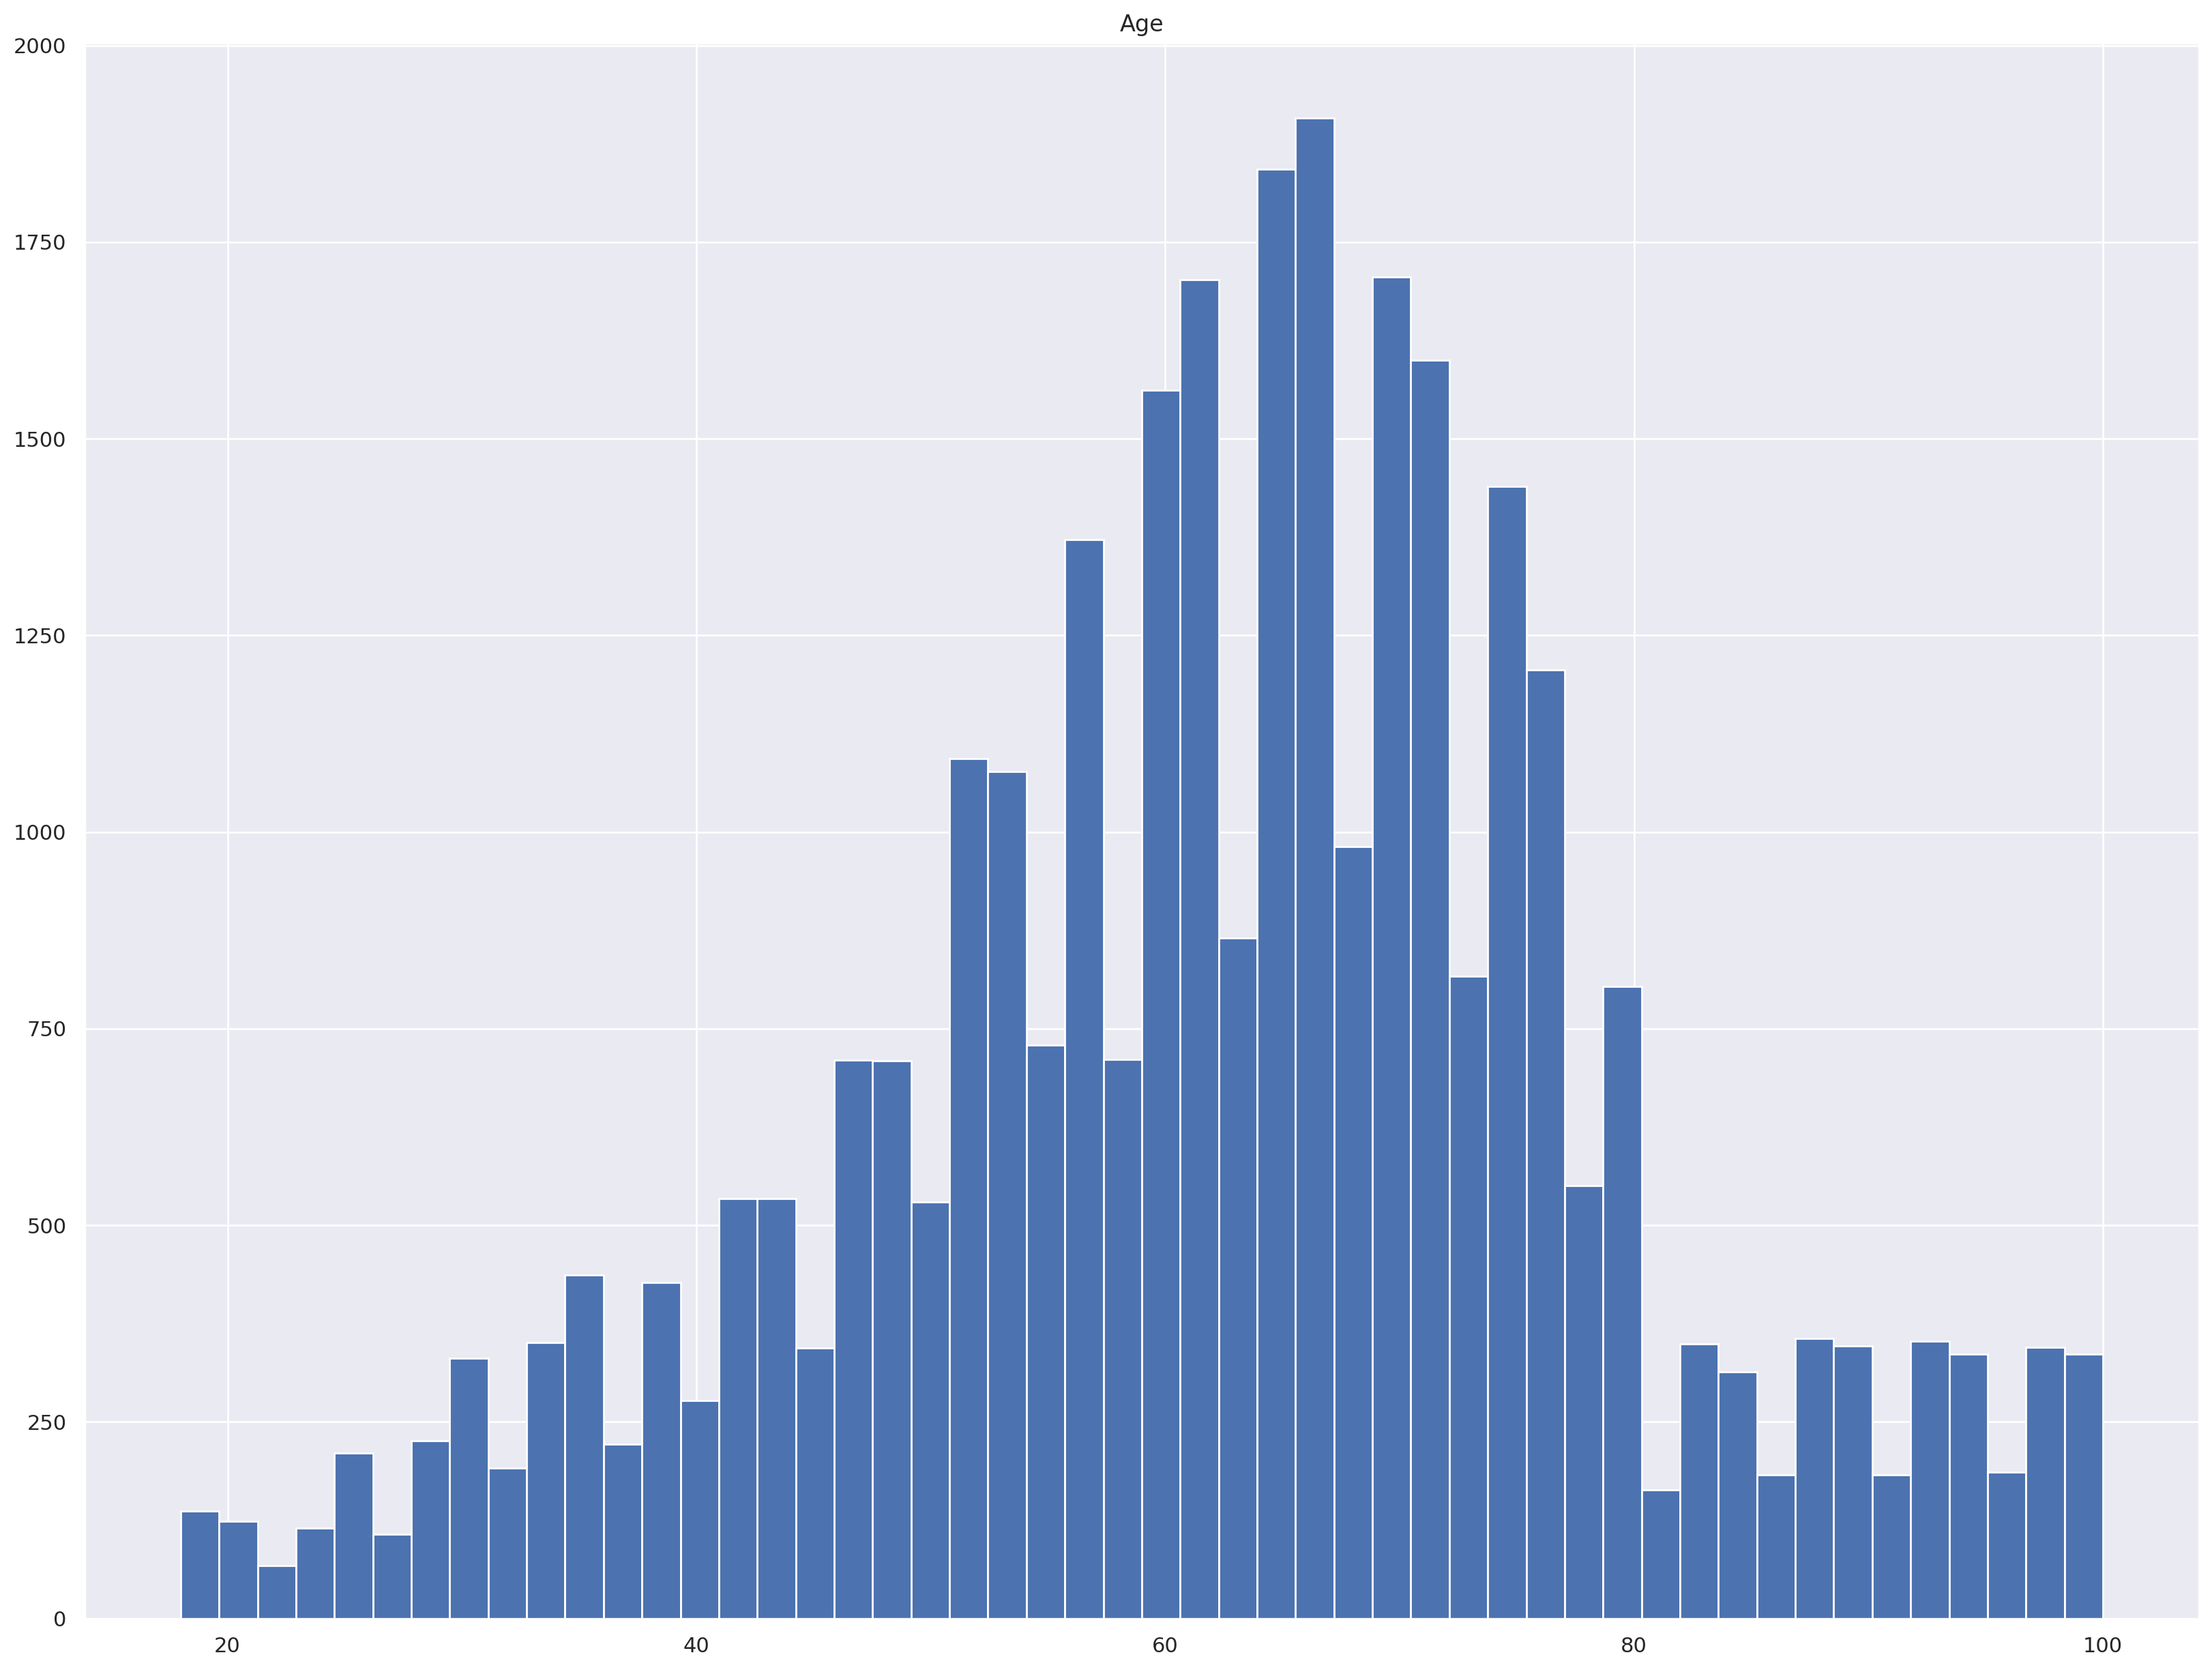

In [57]:
train_df.hist(bins=50, figsize=(20,15))

## Mean

<Figure size 640x480 with 0 Axes>

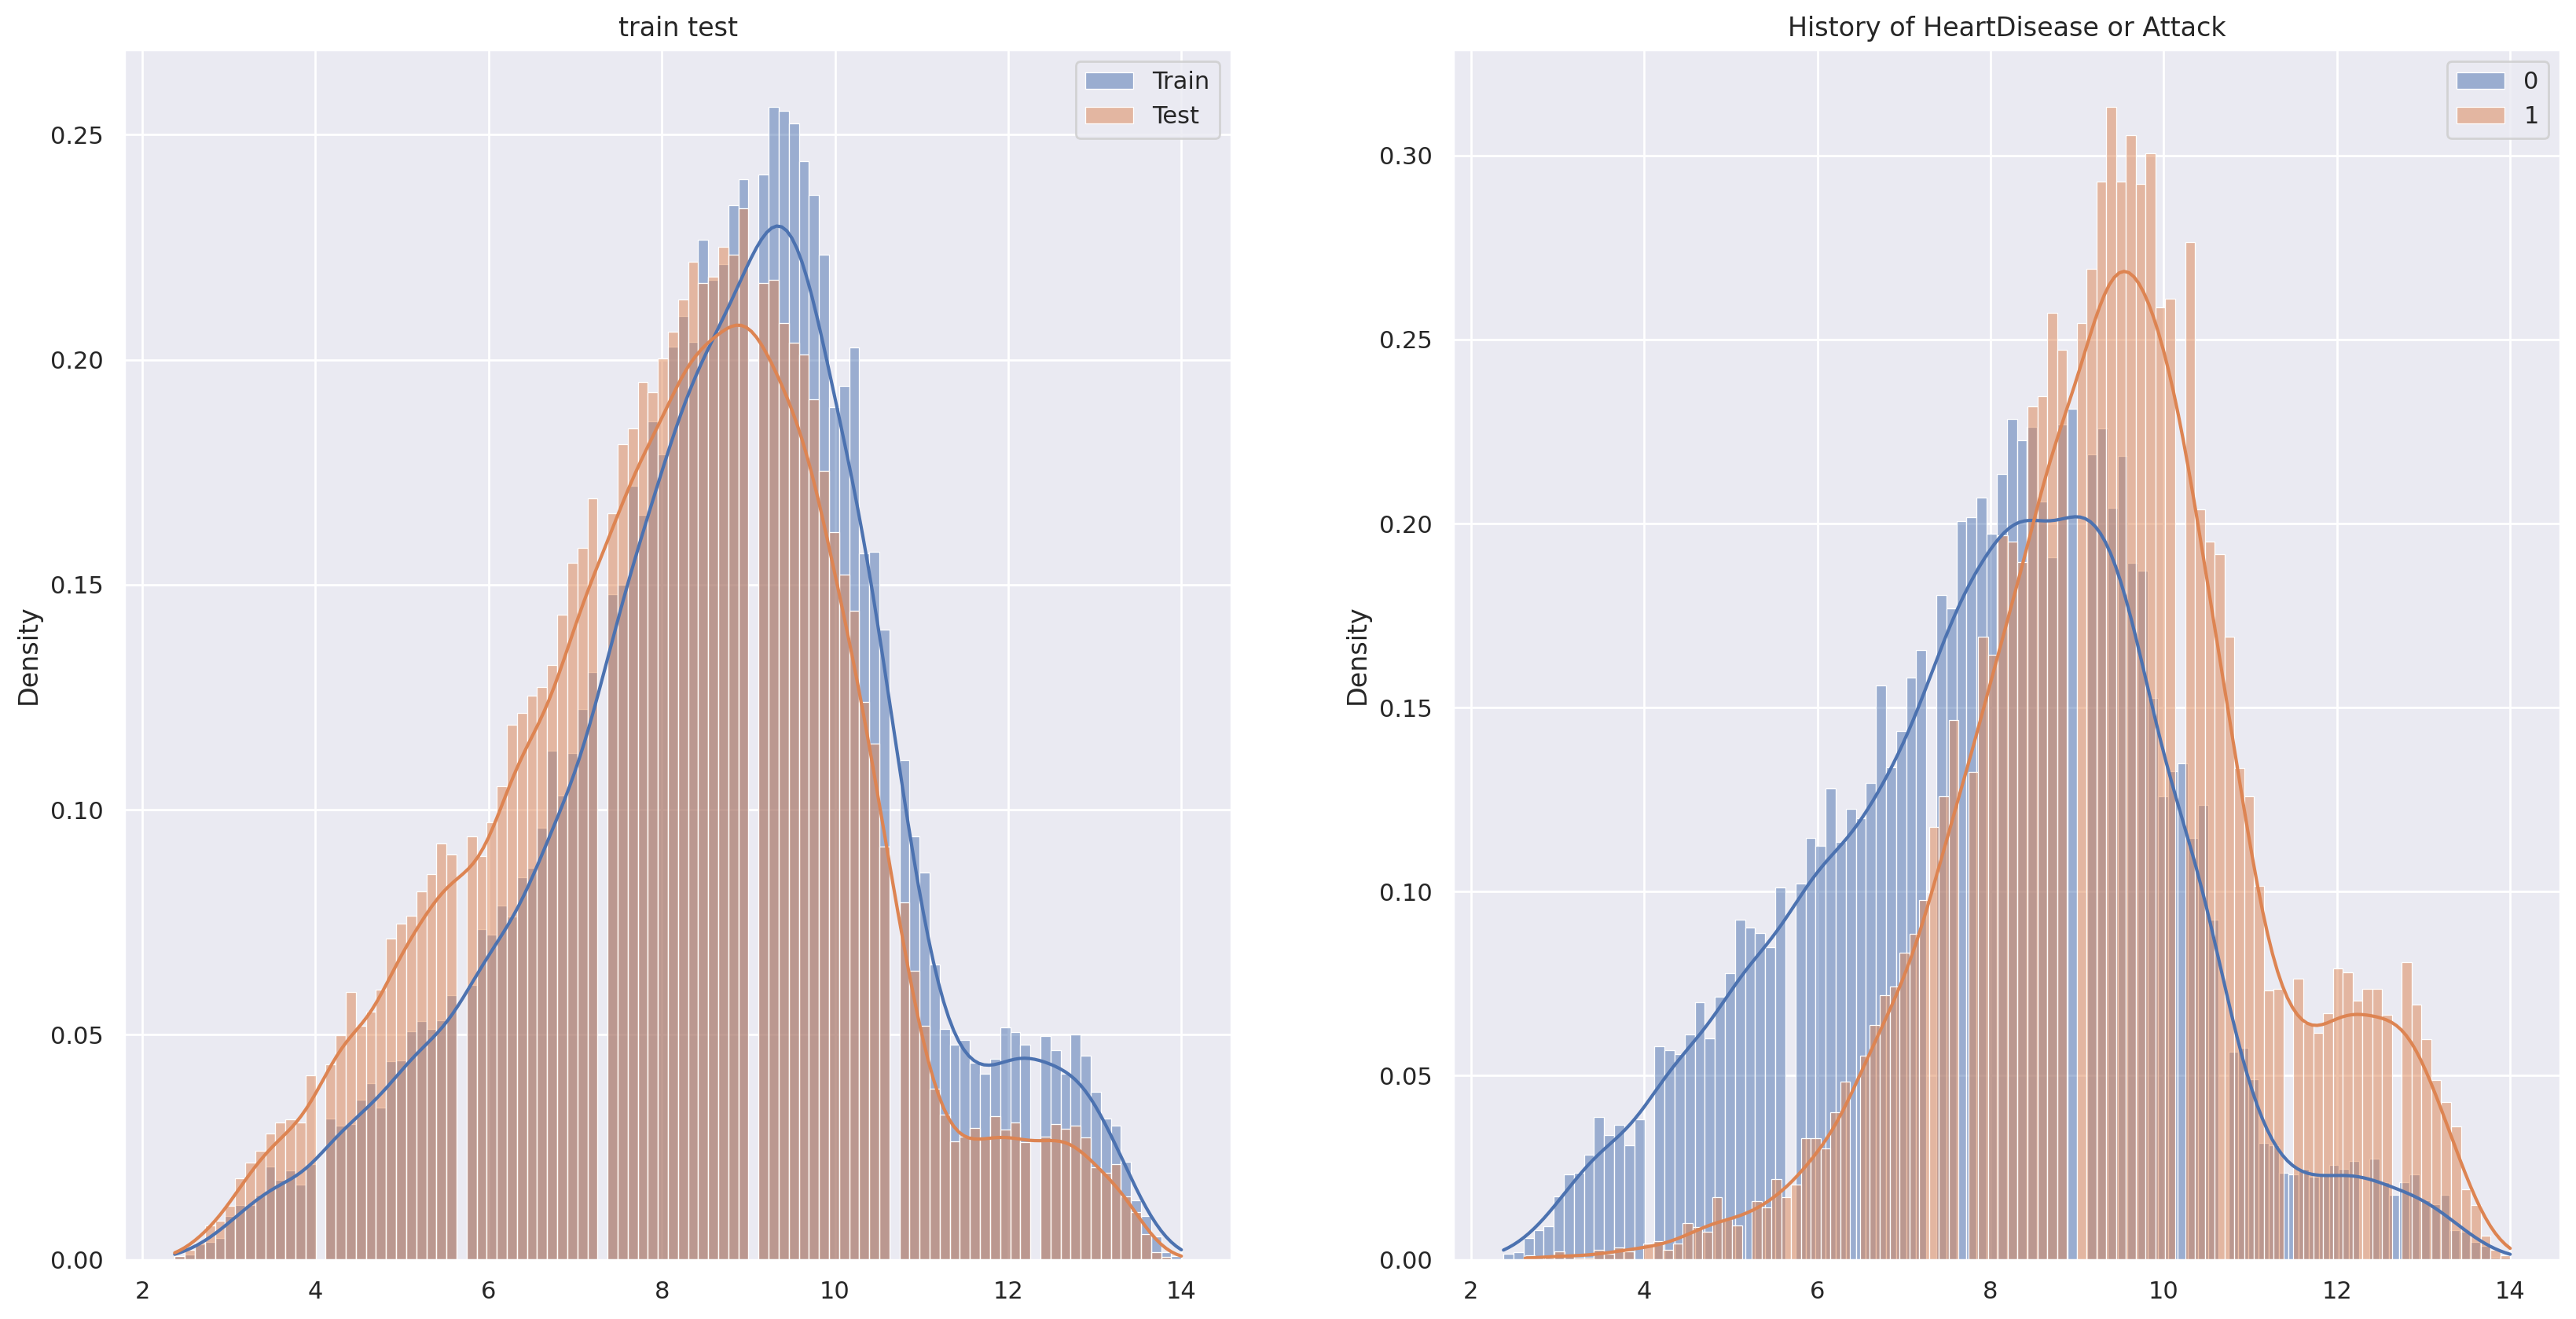

In [62]:
plt.figure()
fig, ax = plt.subplots(1,2,figsize=(20,10))
features = train_df.columns.values[2:21]

plt.subplot(1,2,1)
plt.title("train test")
sns.histplot(data = train_df[features].mean(axis = 1),kde = True,bins = 100,label = "Train",stat = "density")
sns.histplot(data = test_df[features].mean(axis = 1),kde = True,bins = 100,label = "Test",stat = "density")
plt.legend()

uni = train_df['History of HeartDisease or Attack'].nunique()
plt.subplot(1,2,2)
plt.title("History of HeartDisease or Attack")
for i in range(uni):
    sns.histplot(data = train_df[train_df['History of HeartDisease or Attack'] == i][features].mean(axis = 1),kde = True,bins = 100,label = str(i),stat = "density")
plt.legend()

plt.show()

## Standard division

<Figure size 640x480 with 0 Axes>

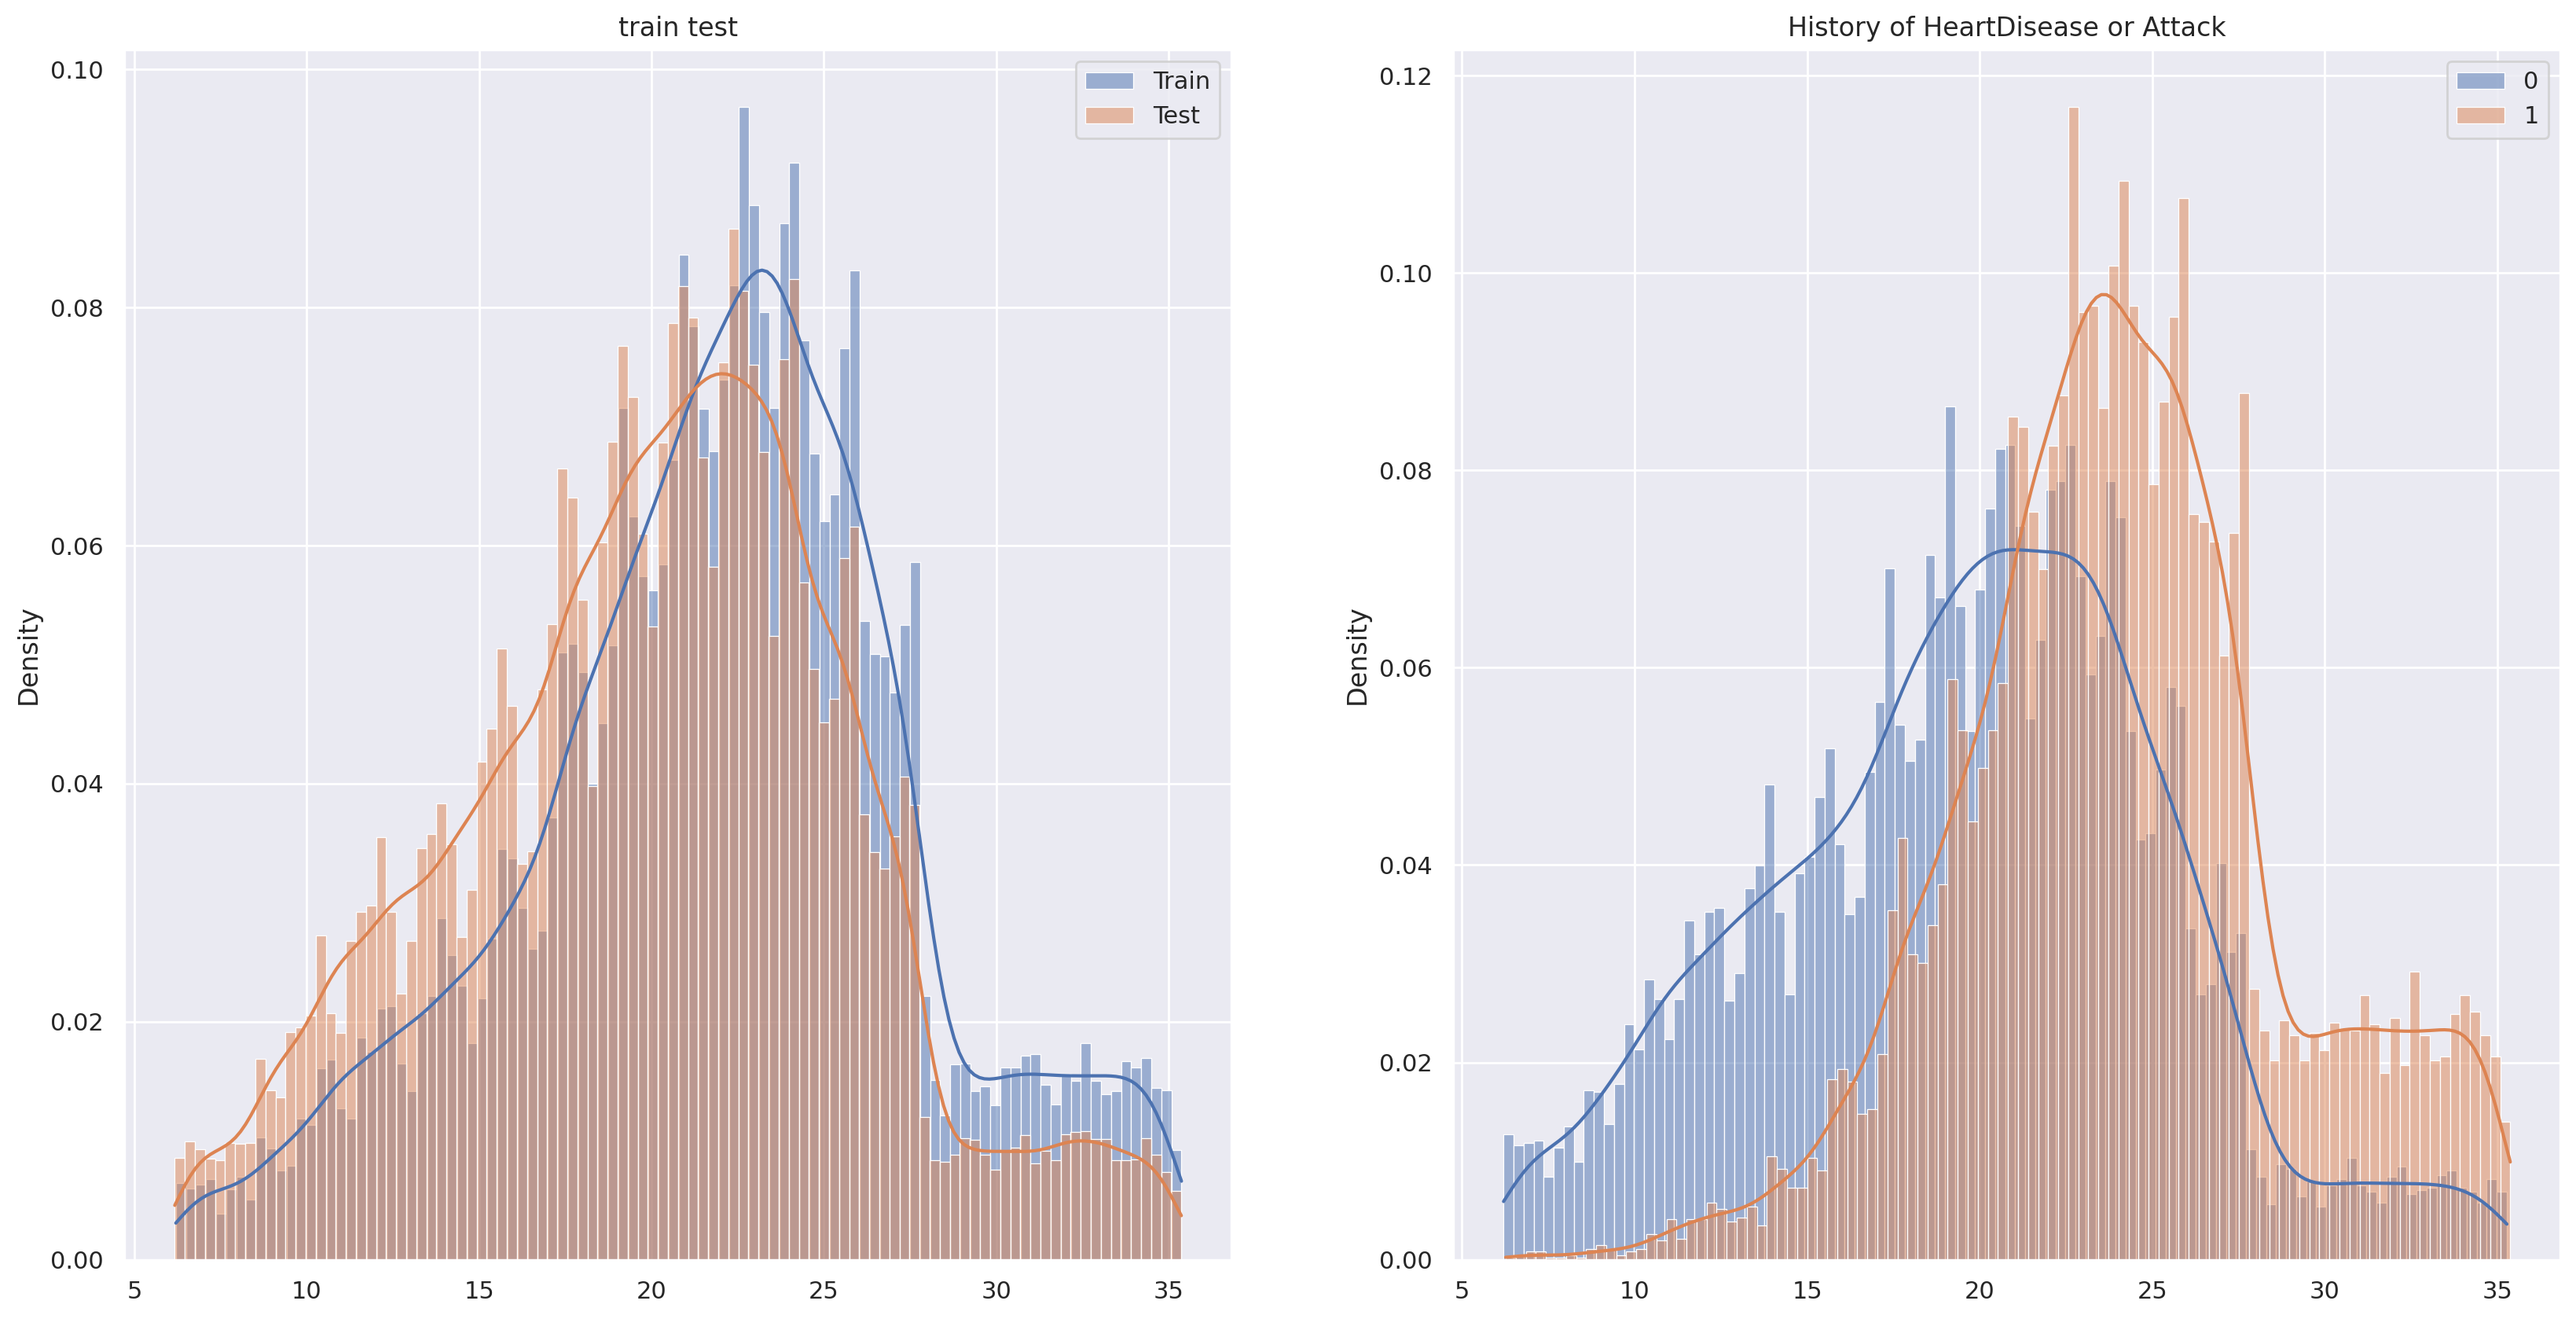

In [61]:
plt.figure()
fig, ax = plt.subplots(1,2,figsize=(20,10))
features = train_df.columns.values[2:21]

plt.subplot(1,2,1)
plt.title("train test")
sns.histplot(data = train_df[features].std(axis = 1),kde = True,bins = 100,label = "Train",stat = "density")
sns.histplot(data = test_df[features].std(axis = 1),kde = True,bins = 100,label = "Test",stat = "density")
plt.legend()

uni = train_df['History of HeartDisease or Attack'].nunique()
plt.subplot(1,2,2)
plt.title("History of HeartDisease or Attack")
for i in range(uni):
    sns.histplot(data = train_df[train_df['History of HeartDisease or Attack'] == i][features].std(axis = 1),kde = True,bins = 100,label = str(i),stat = "density")
plt.legend()

plt.show()

## Min

<Figure size 640x480 with 0 Axes>

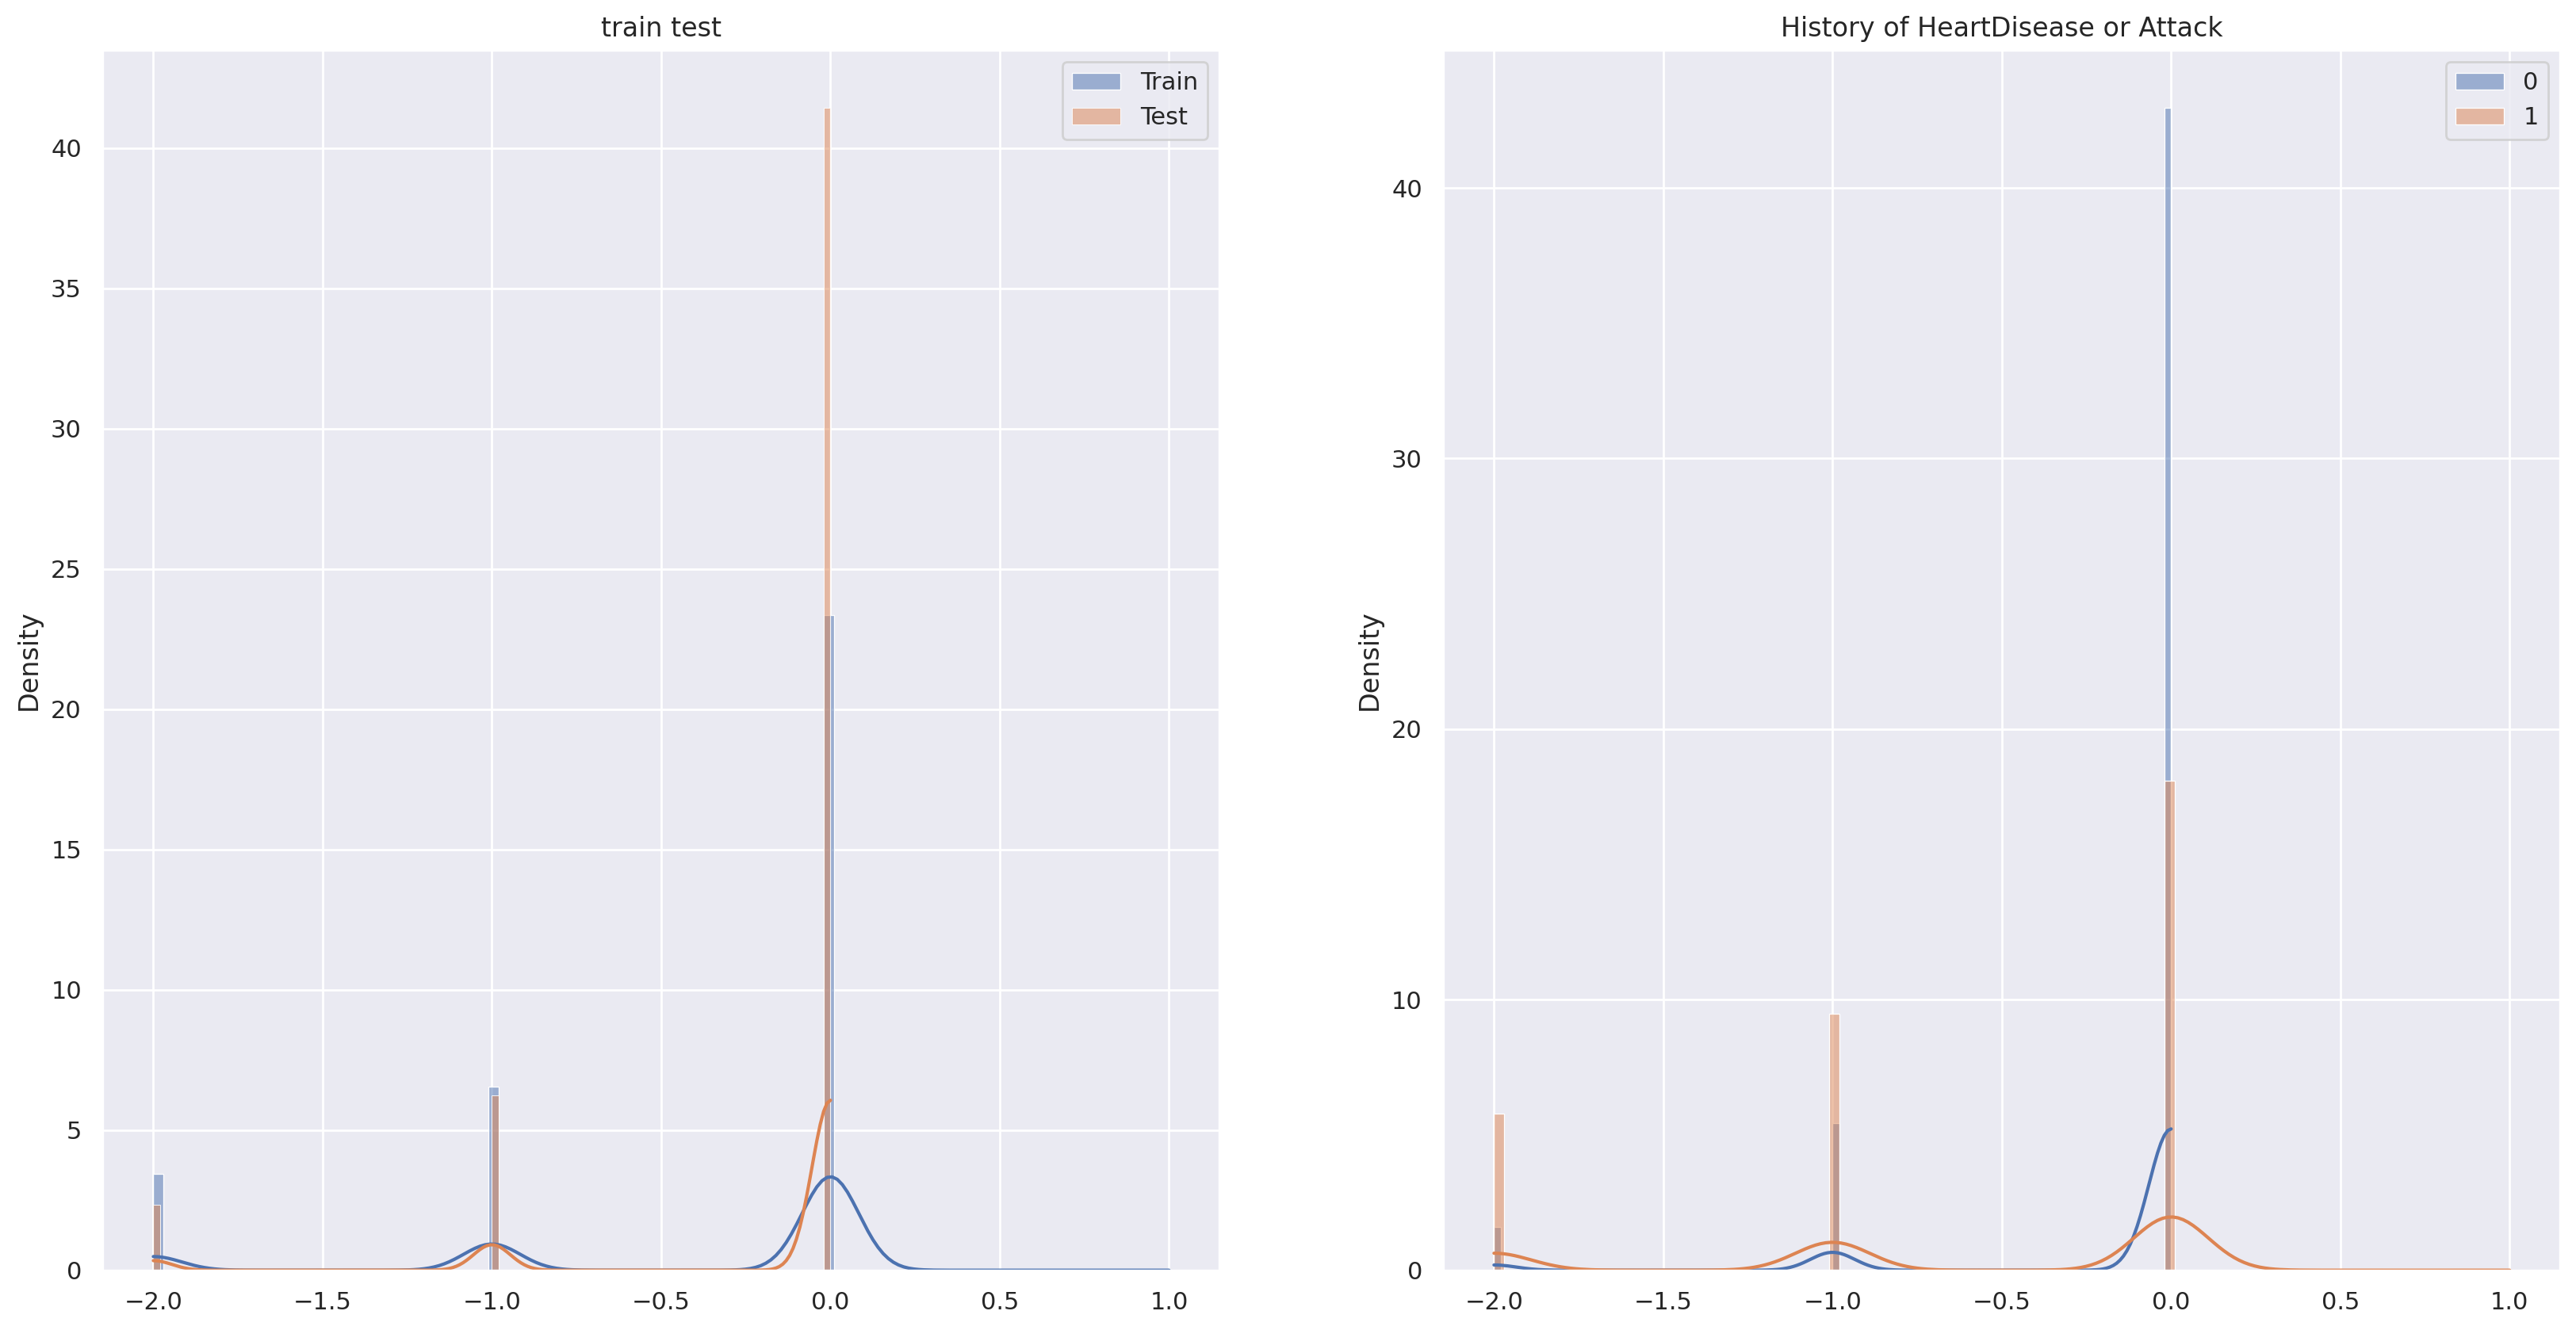

In [73]:
plt.figure()
fig, ax = plt.subplots(1,2,figsize=(20,10))
features = train_df.columns.values[2:21]

plt.subplot(1,2,1)
plt.title("train test")
sns.histplot(data = train_df[features].min(axis = 1),kde = True,bins = 100,label = "Train",stat = "density")
sns.histplot(data = test_df[features].min(axis = 1),kde = True,bins = 100,label = "Test",stat = "density")
plt.legend()

uni = train_df['History of HeartDisease or Attack'].nunique()
plt.subplot(1,2,2)
plt.title("History of HeartDisease or Attack")
for i in range(uni):
    sns.histplot(data = train_df[train_df['History of HeartDisease or Attack'] == i][features].min(axis = 1),kde = True,bins = 100,label = str(i),stat = "density")
plt.legend()

plt.show()

## Max

<Figure size 640x480 with 0 Axes>

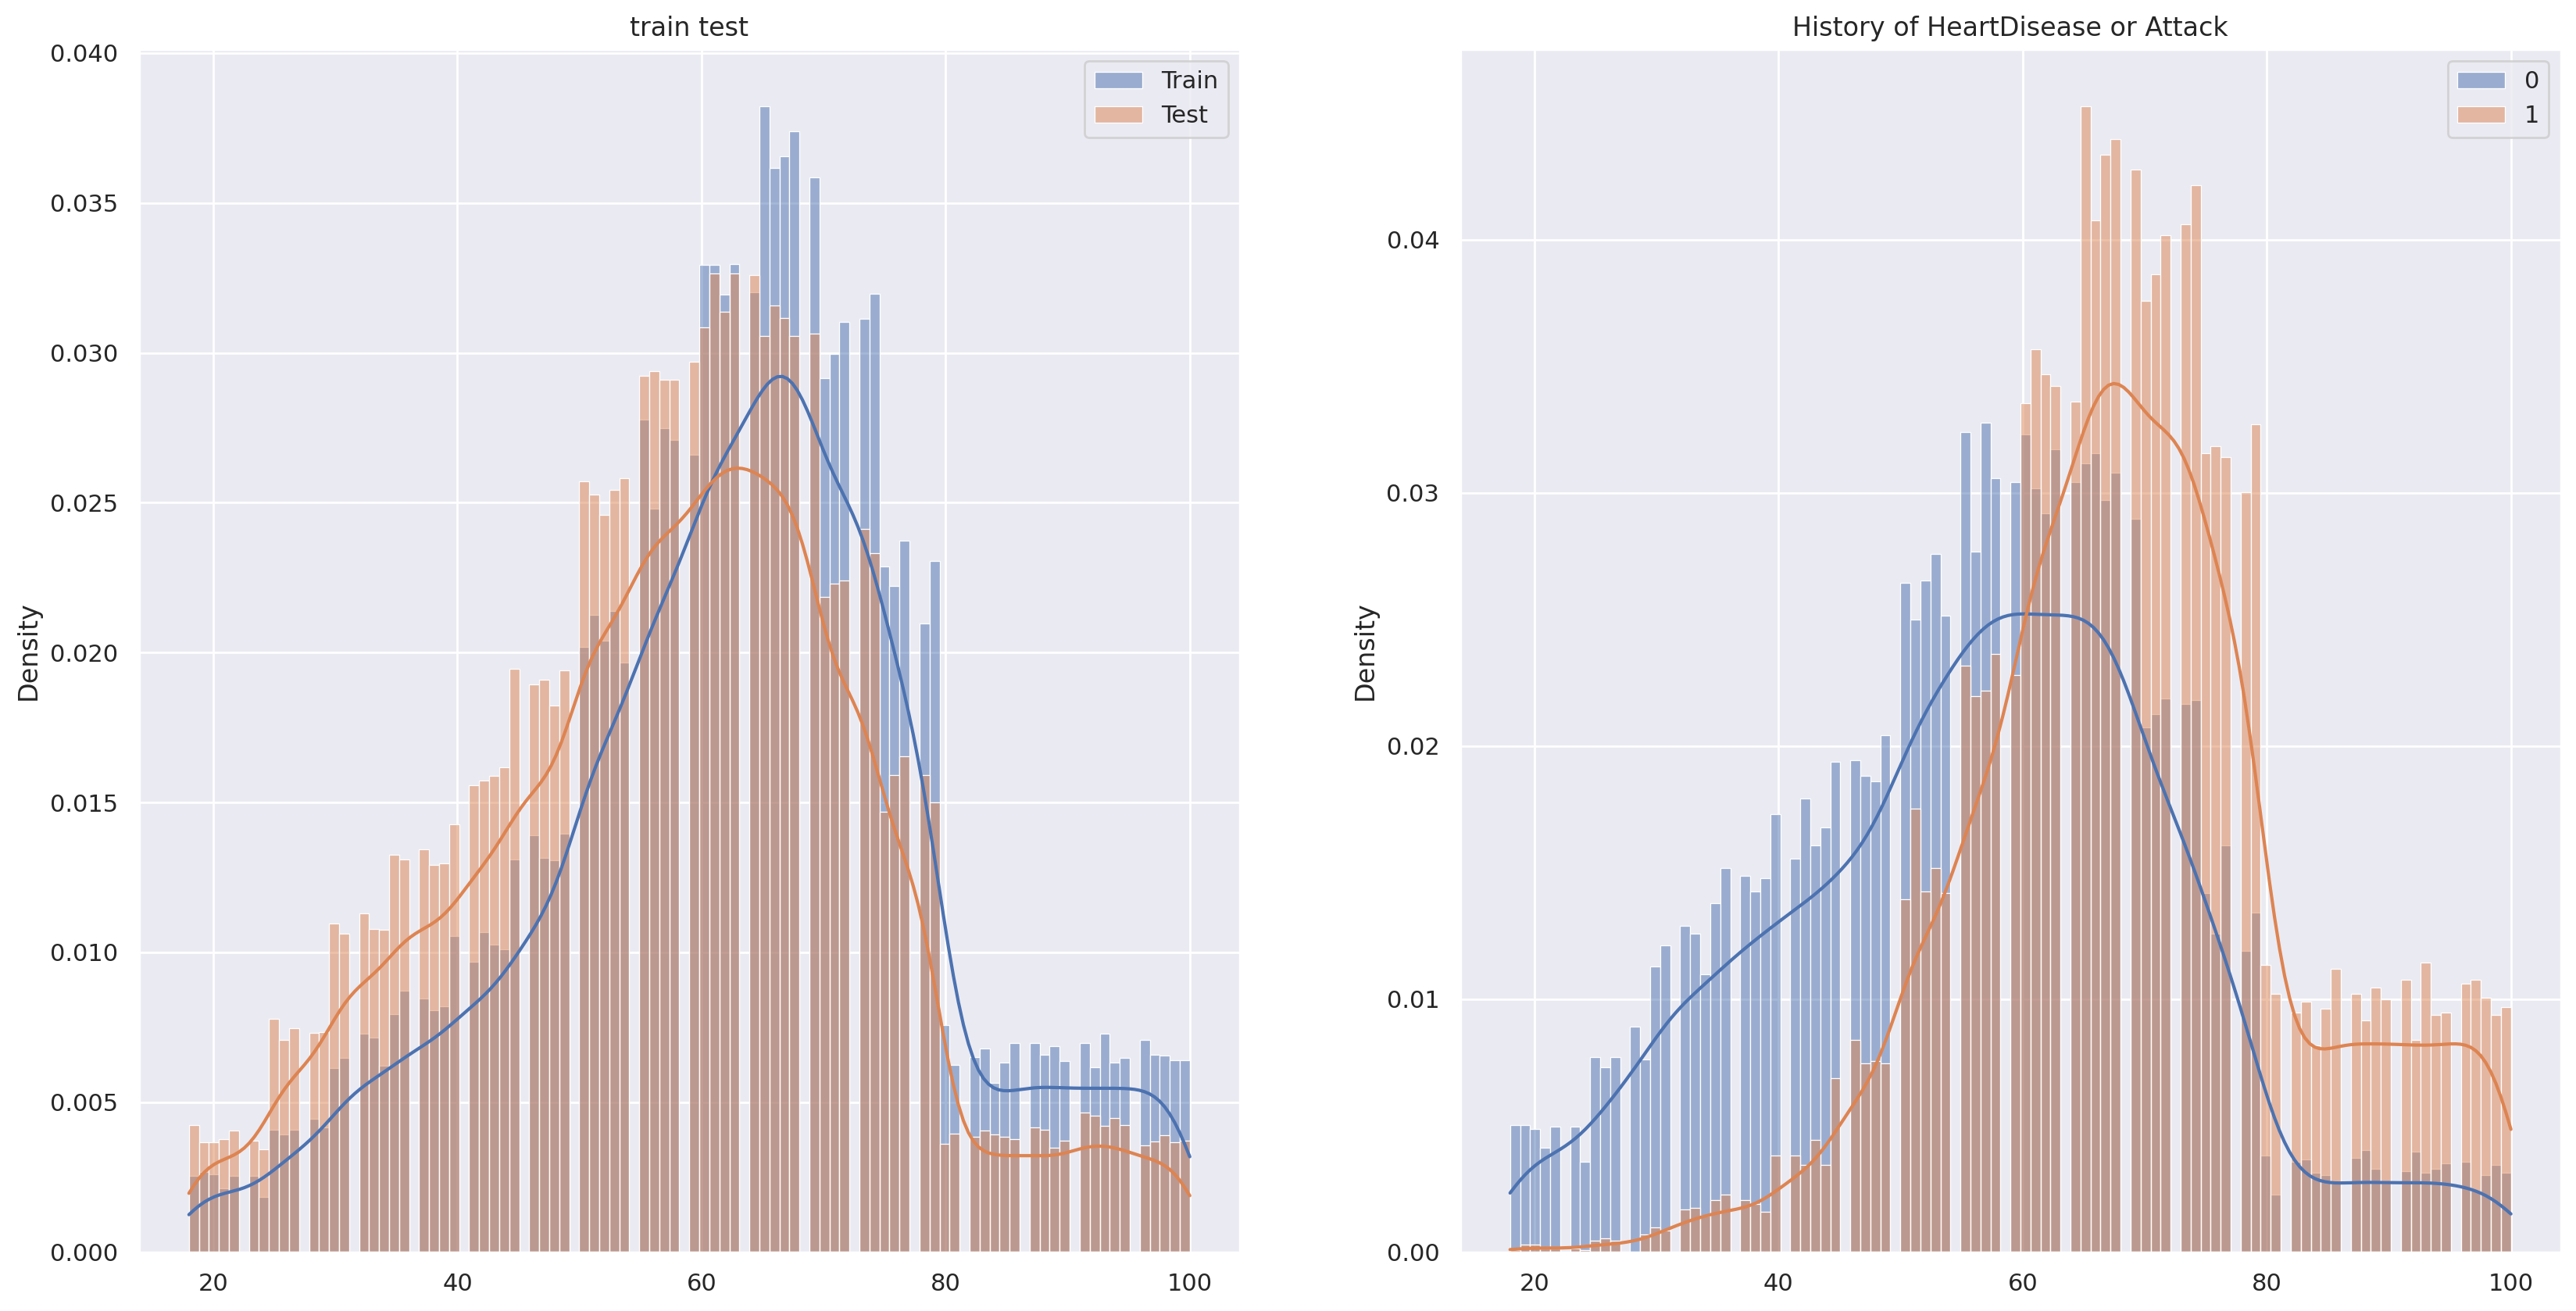

In [72]:
plt.figure()
fig, ax = plt.subplots(1,2,figsize=(20,10))
features = train_df.columns.values[2:21]

plt.subplot(1,2,1)
plt.title("train test")
sns.histplot(data = train_df[features].max(axis = 1),kde = True,bins = 100,label = "Train",stat = "density")
sns.histplot(data = test_df[features].max(axis = 1),kde = True,bins = 100,label = "Test",stat = "density")
plt.legend()

uni = train_df['History of HeartDisease or Attack'].nunique()
plt.subplot(1,2,2)
plt.title("History of HeartDisease or Attack")
for i in range(uni):
    sns.histplot(data = train_df[train_df['History of HeartDisease or Attack'] == i][features].max(axis = 1),kde = True,bins = 100,label = str(i),stat = "density")
plt.legend()

plt.show()

## Medain

<Figure size 640x480 with 0 Axes>

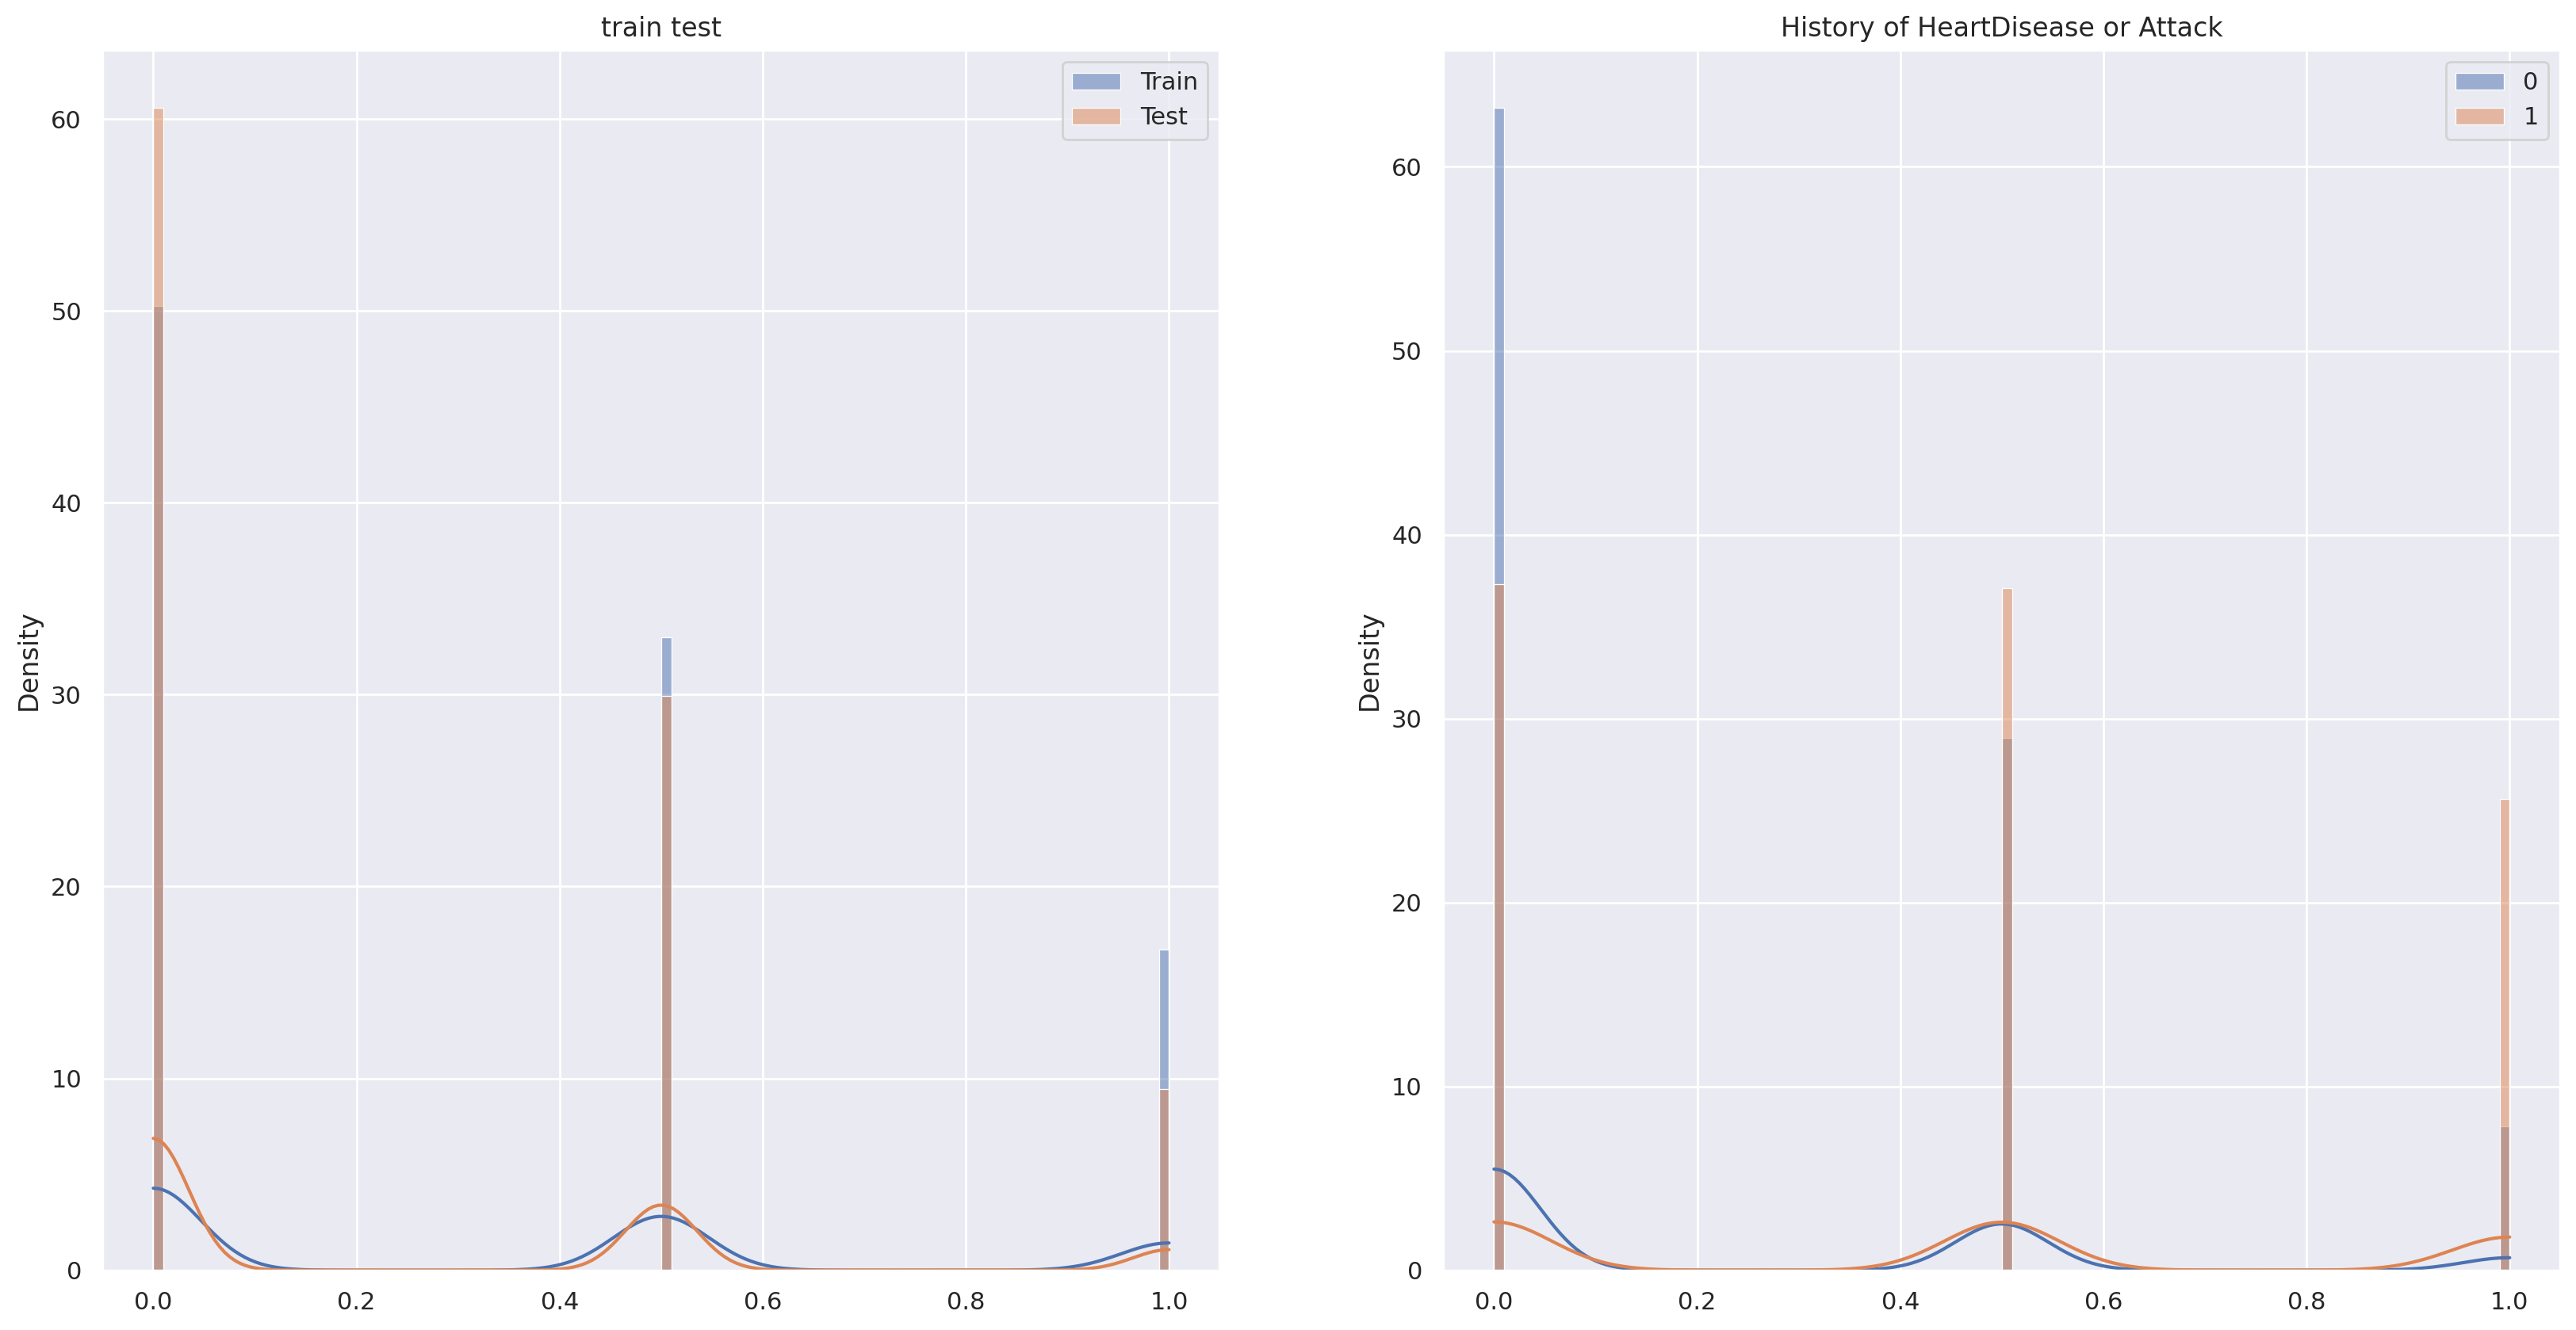

In [71]:
plt.figure()
fig, ax = plt.subplots(1,2,figsize=(20,10))
features = train_df.columns.values[2:21]

plt.subplot(1,2,1)
plt.title("train test")
sns.histplot(data = train_df[features].median(axis = 1),kde = True,bins = 100,label = "Train",stat = "density")
sns.histplot(data = test_df[features].median(axis = 1),kde = True,bins = 100,label = "Test",stat = "density")
plt.legend()

uni = train_df['History of HeartDisease or Attack'].nunique()
plt.subplot(1,2,2)
plt.title("History of HeartDisease or Attack")
for i in range(uni):
    sns.histplot(data = train_df[train_df['History of HeartDisease or Attack'] == i][features].median(axis = 1),kde = True,bins = 100,label = str(i),stat = "density")
plt.legend()

plt.show()

## Summation

<Figure size 640x480 with 0 Axes>

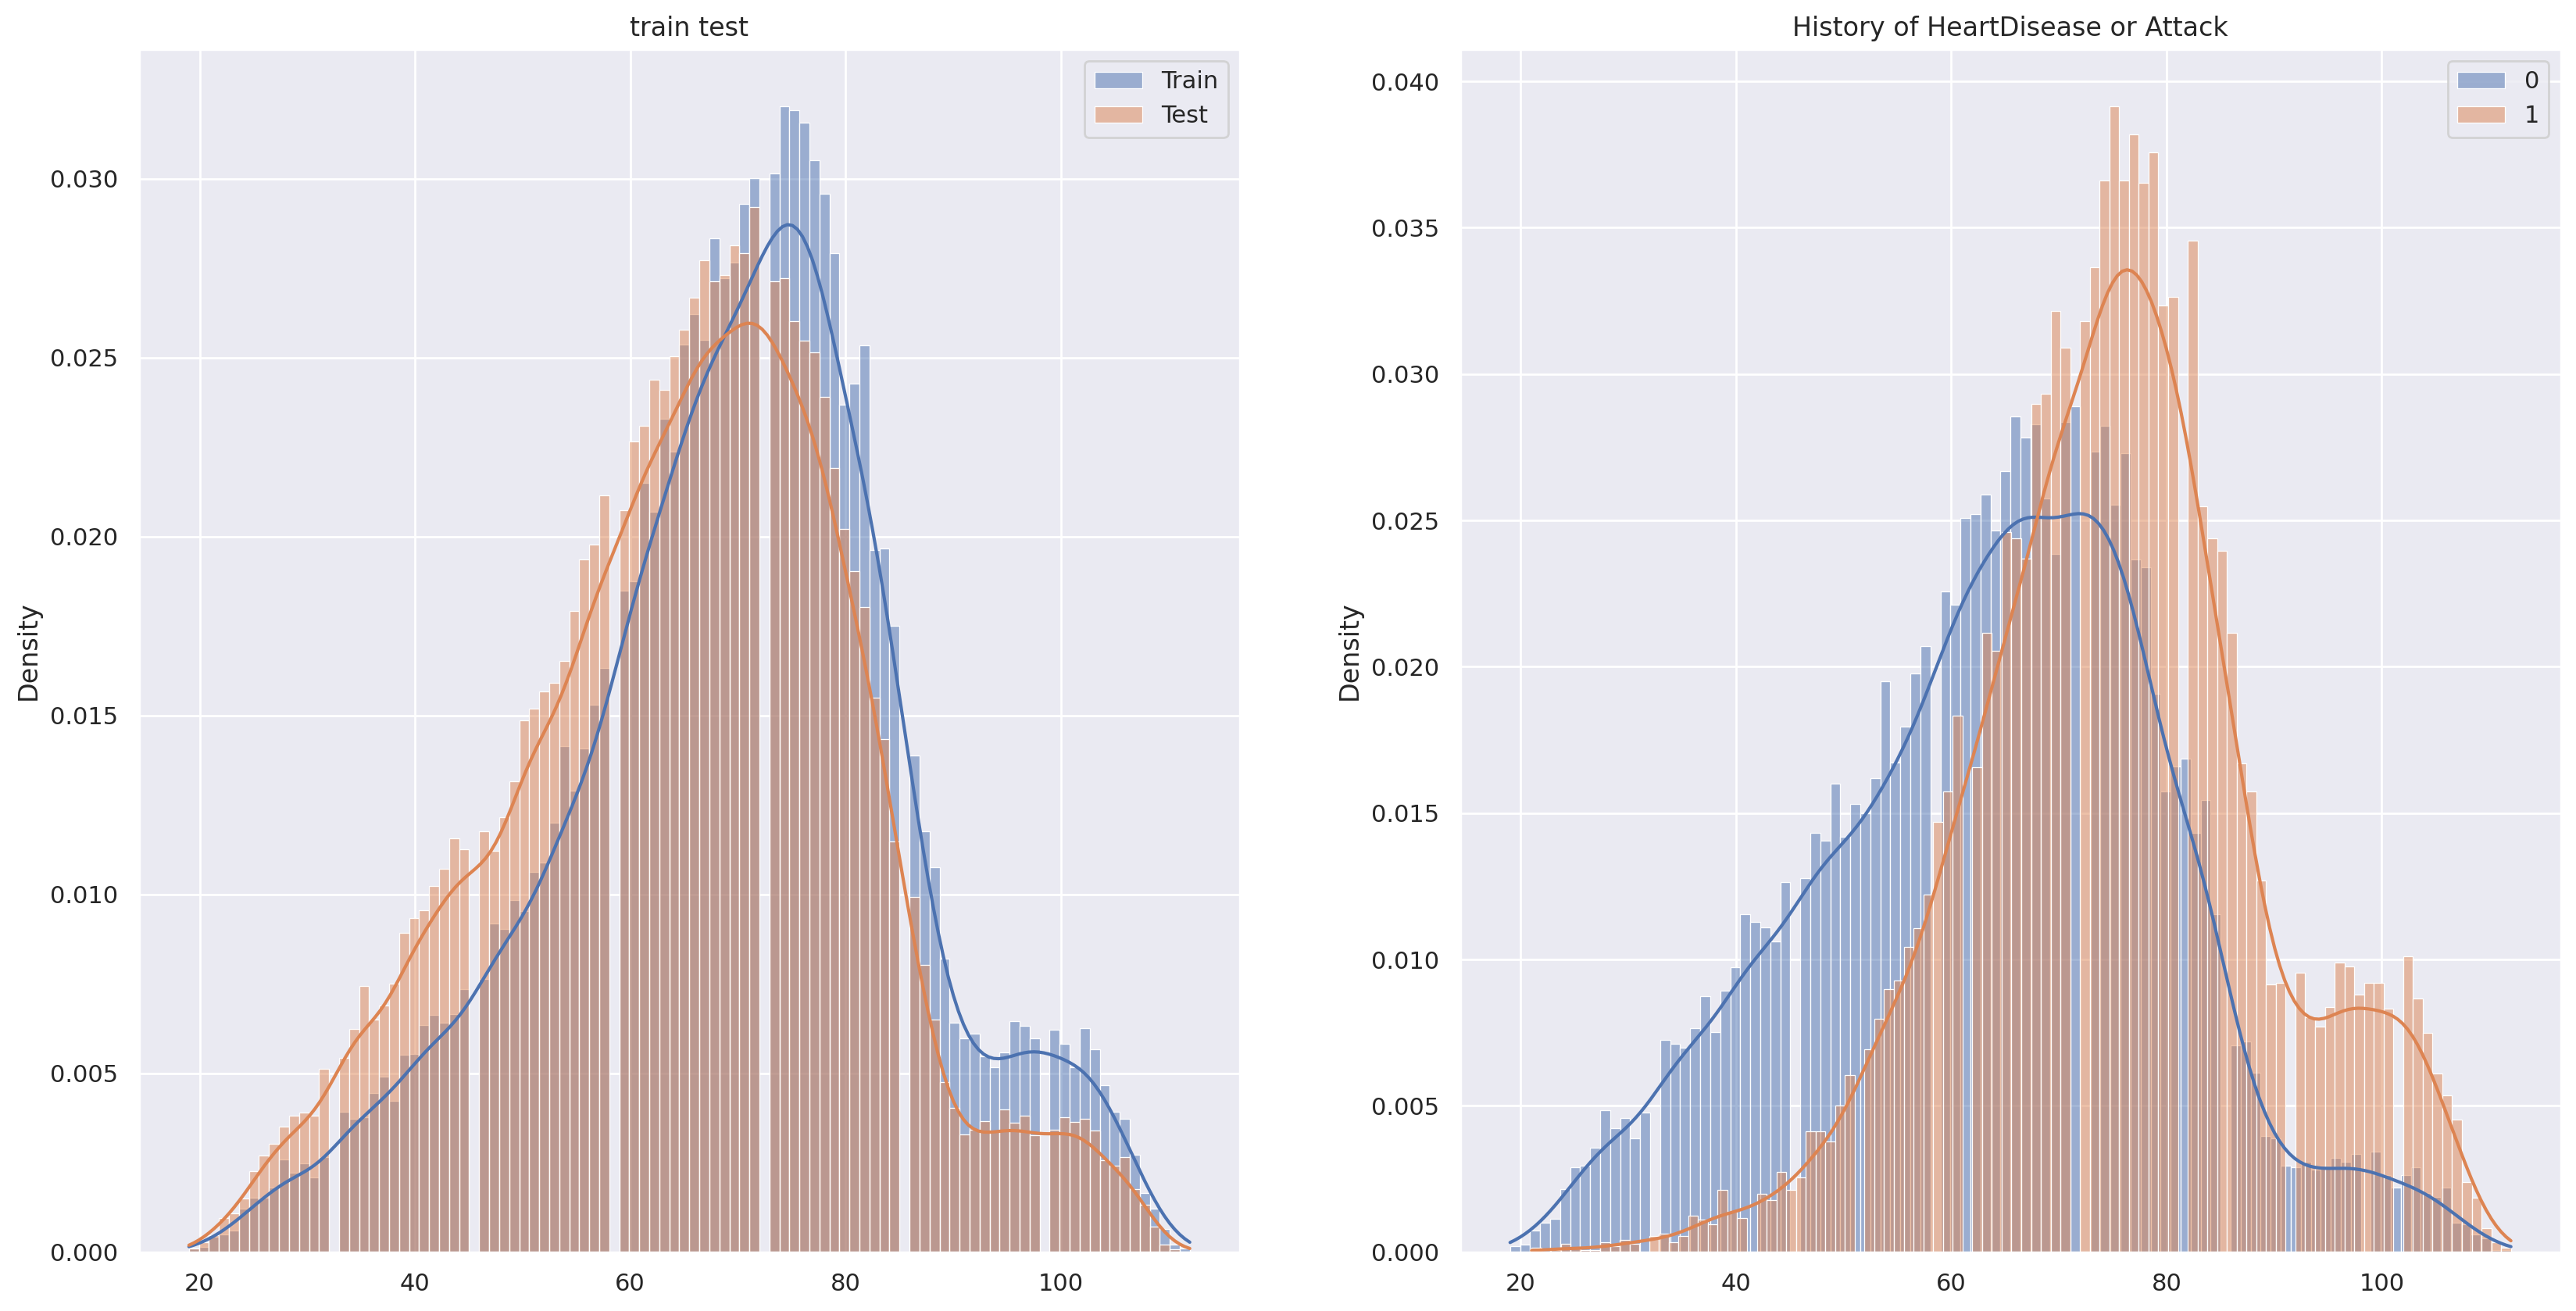

In [70]:
plt.figure()
fig, ax = plt.subplots(1,2,figsize=(20,10))
features = train_df.columns.values[2:21]

plt.subplot(1,2,1)
plt.title("train test")
sns.histplot(data = train_df[features].sum(axis = 1),kde = True,bins = 100,label = "Train",stat = "density")
sns.histplot(data = test_df[features].sum(axis = 1),kde = True,bins = 100,label = "Test",stat = "density")
plt.legend()

uni = train_df['History of HeartDisease or Attack'].nunique()
plt.subplot(1,2,2)
plt.title("History of HeartDisease or Attack")
for i in range(uni):
    sns.histplot(data = train_df[train_df['History of HeartDisease or Attack'] == i][features].sum(axis = 1),kde = True,bins = 100,label = str(i),stat = "density")
plt.legend()

plt.show()

## Skew

<Figure size 640x480 with 0 Axes>

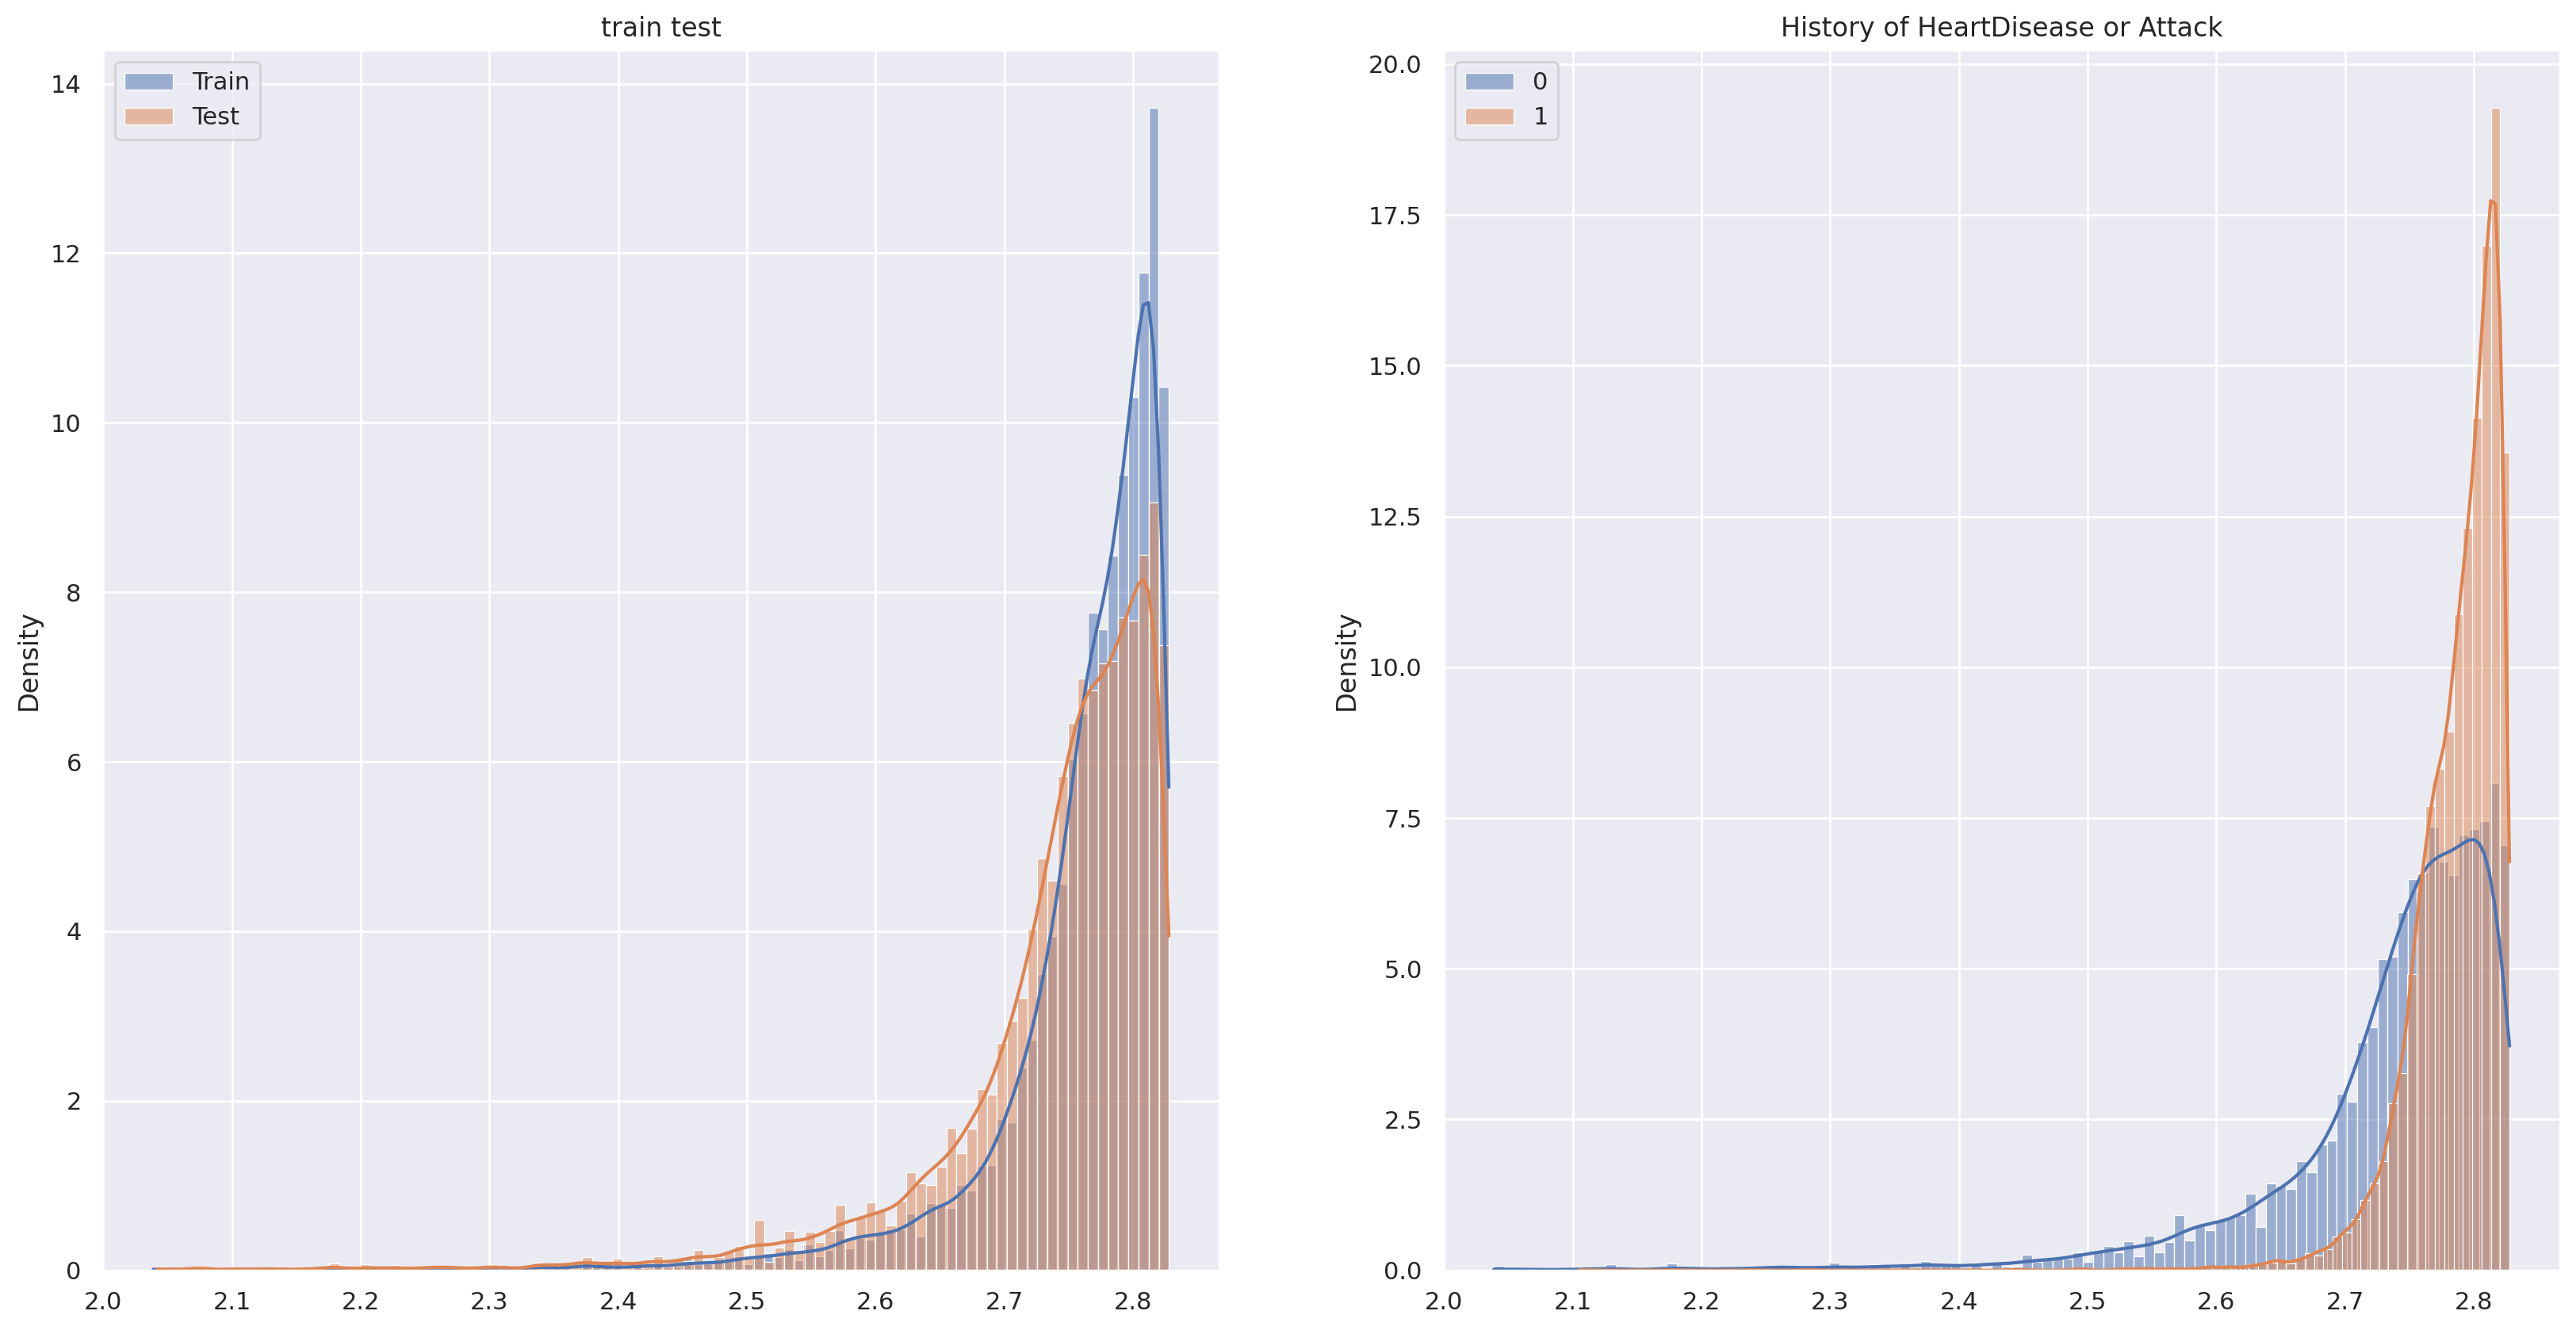

In [69]:
plt.figure()
fig, ax = plt.subplots(1,2,figsize=(20,10))
features = train_df.columns.values[2:21]

plt.subplot(1,2,1)
plt.title("train test")
sns.histplot(data = train_df[features].skew(axis = 1),kde = True,bins = 100,label = "Train",stat = "density")
sns.histplot(data = test_df[features].skew(axis = 1),kde = True,bins = 100,label = "Test",stat = "density")
plt.legend()

uni = train_df['History of HeartDisease or Attack'].nunique()
plt.subplot(1,2,2)
plt.title("History of HeartDisease or Attack")
for i in range(uni):
    sns.histplot(data = train_df[train_df['History of HeartDisease or Attack'] == i][features].skew(axis = 1),kde = True,bins = 100,label = str(i),stat = "density")
plt.legend()

plt.show()

## Kurtosis

<Figure size 640x480 with 0 Axes>

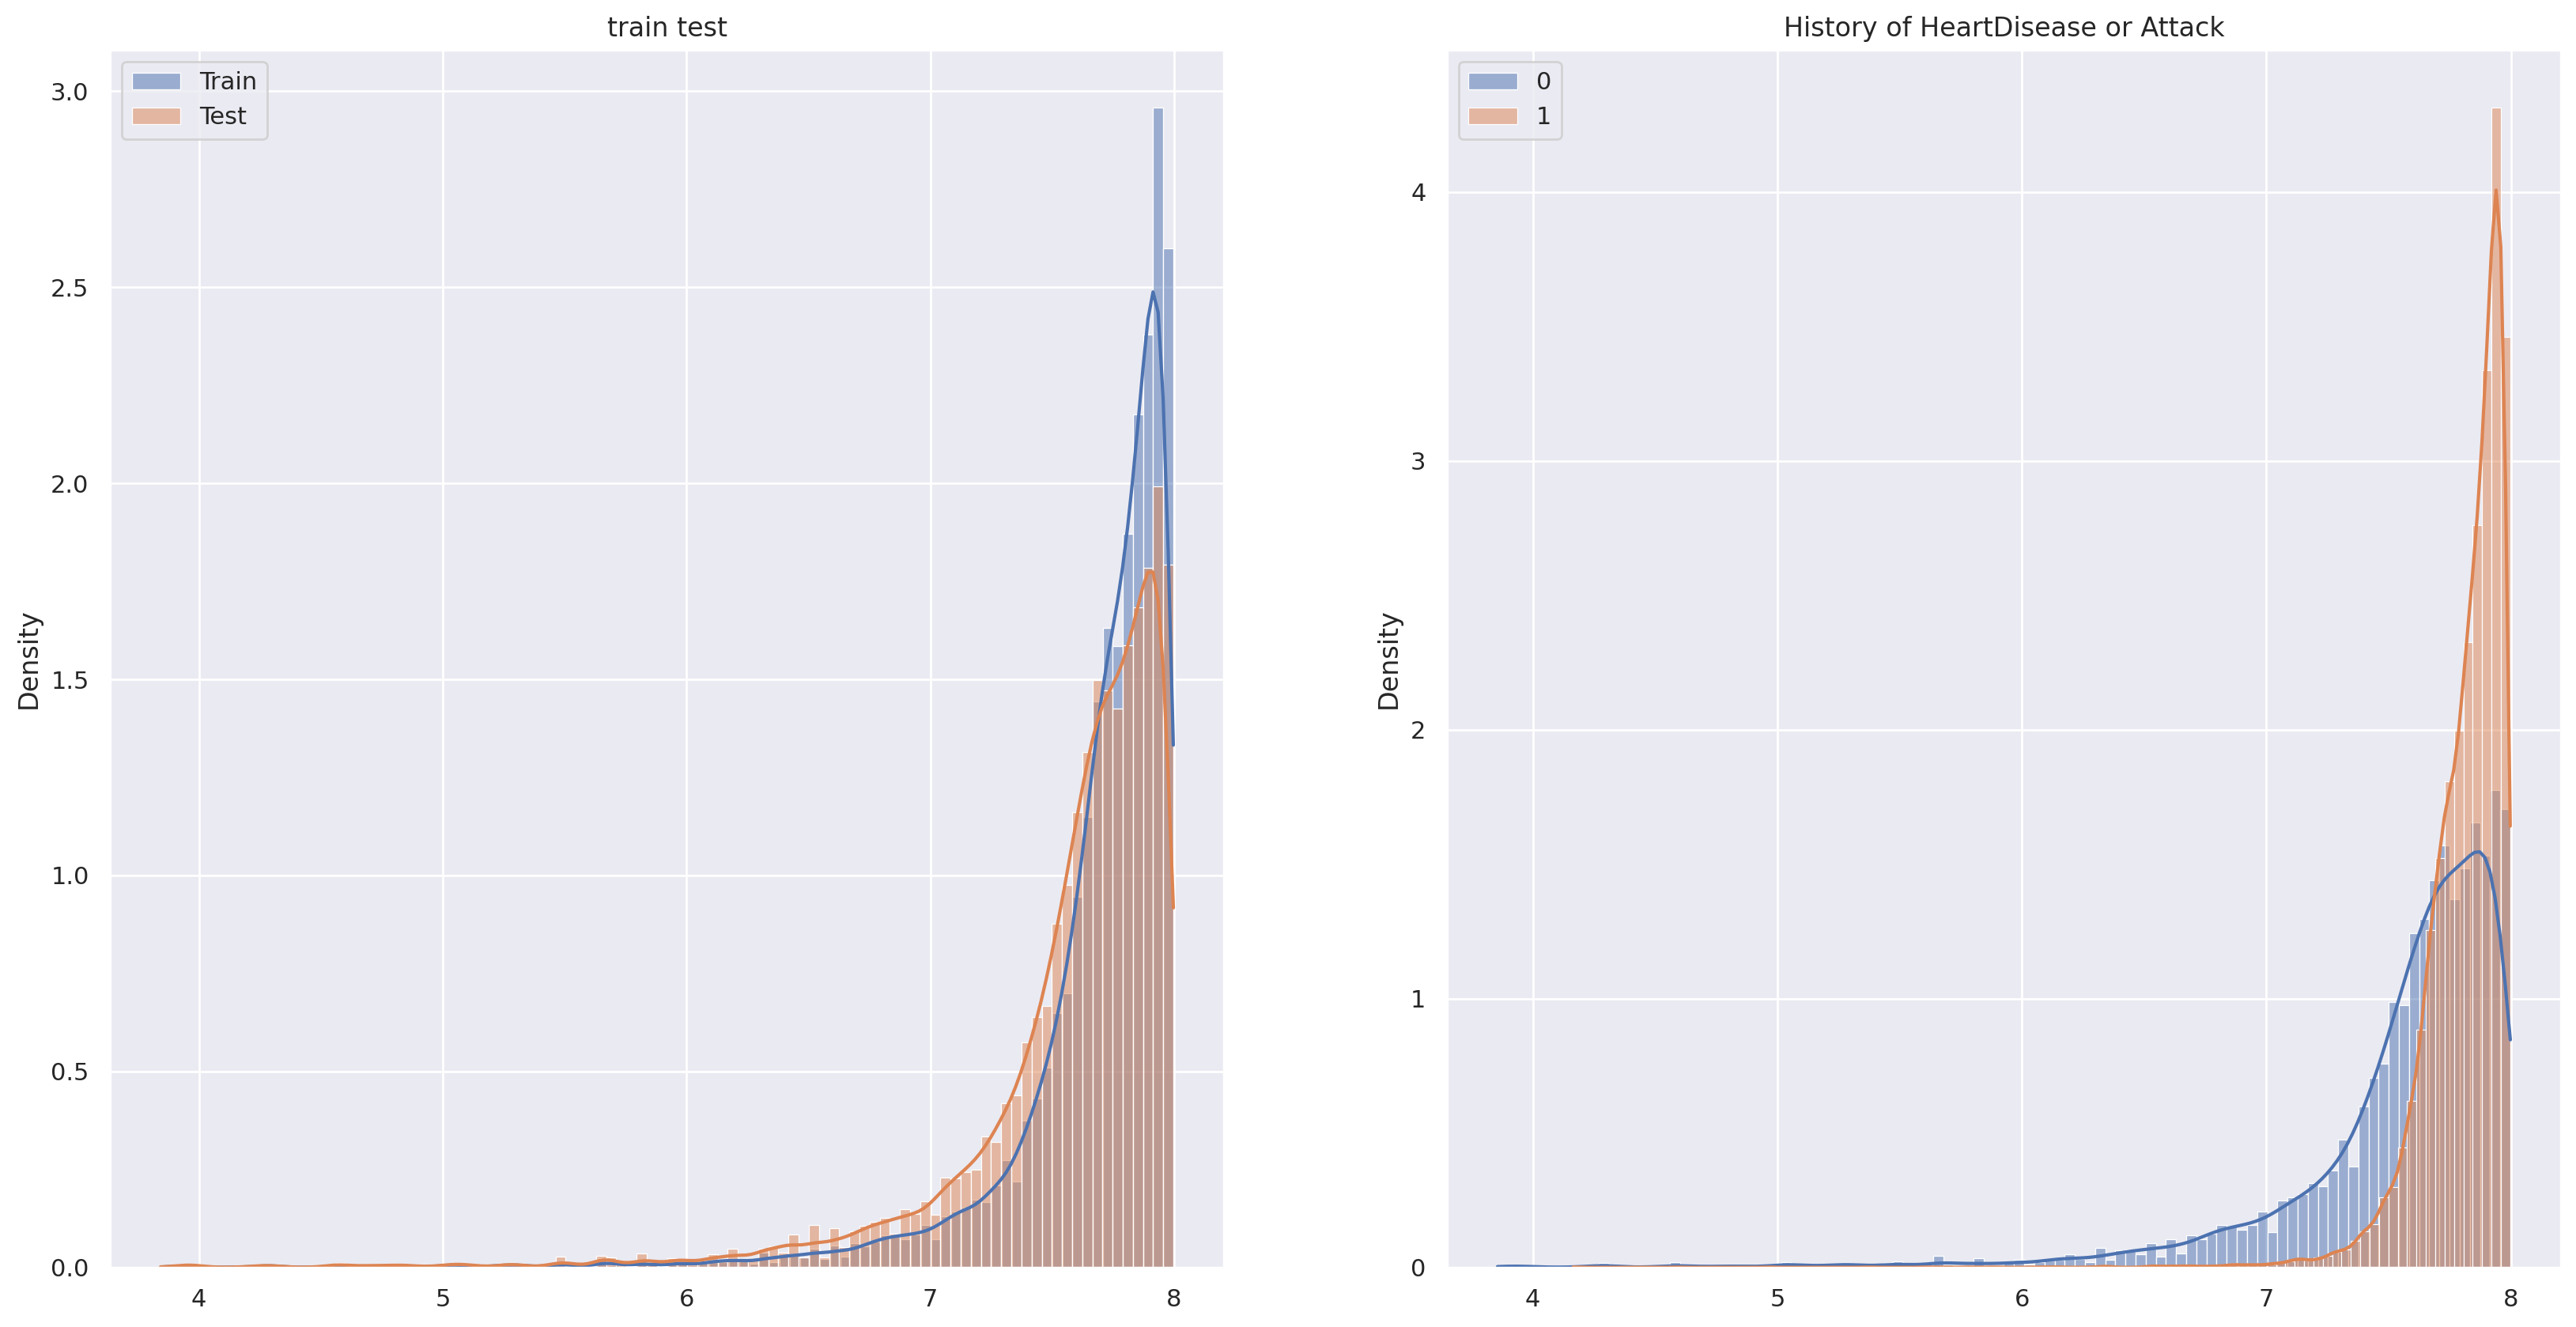

In [68]:
plt.figure()
fig, ax = plt.subplots(1,2,figsize=(20,10))
features = train_df.columns.values[2:21]

plt.subplot(1,2,1)
plt.title("train test")
sns.histplot(data = train_df[features].kurt(axis = 1),kde = True,bins = 100,label = "Train",stat = "density")
sns.histplot(data = test_df[features].kurt(axis = 1),kde = True,bins = 100,label = "Test",stat = "density")
plt.legend()

uni = train_df['History of HeartDisease or Attack'].nunique()
plt.subplot(1,2,2)
plt.title("History of HeartDisease or Attack")
for i in range(uni):
    sns.histplot(data = train_df[train_df['History of HeartDisease or Attack'] == i][features].kurt(axis = 1),kde = True,bins = 100,label = str(i),stat = "density")
plt.legend()

plt.show()

## Correlation

<Axes: >

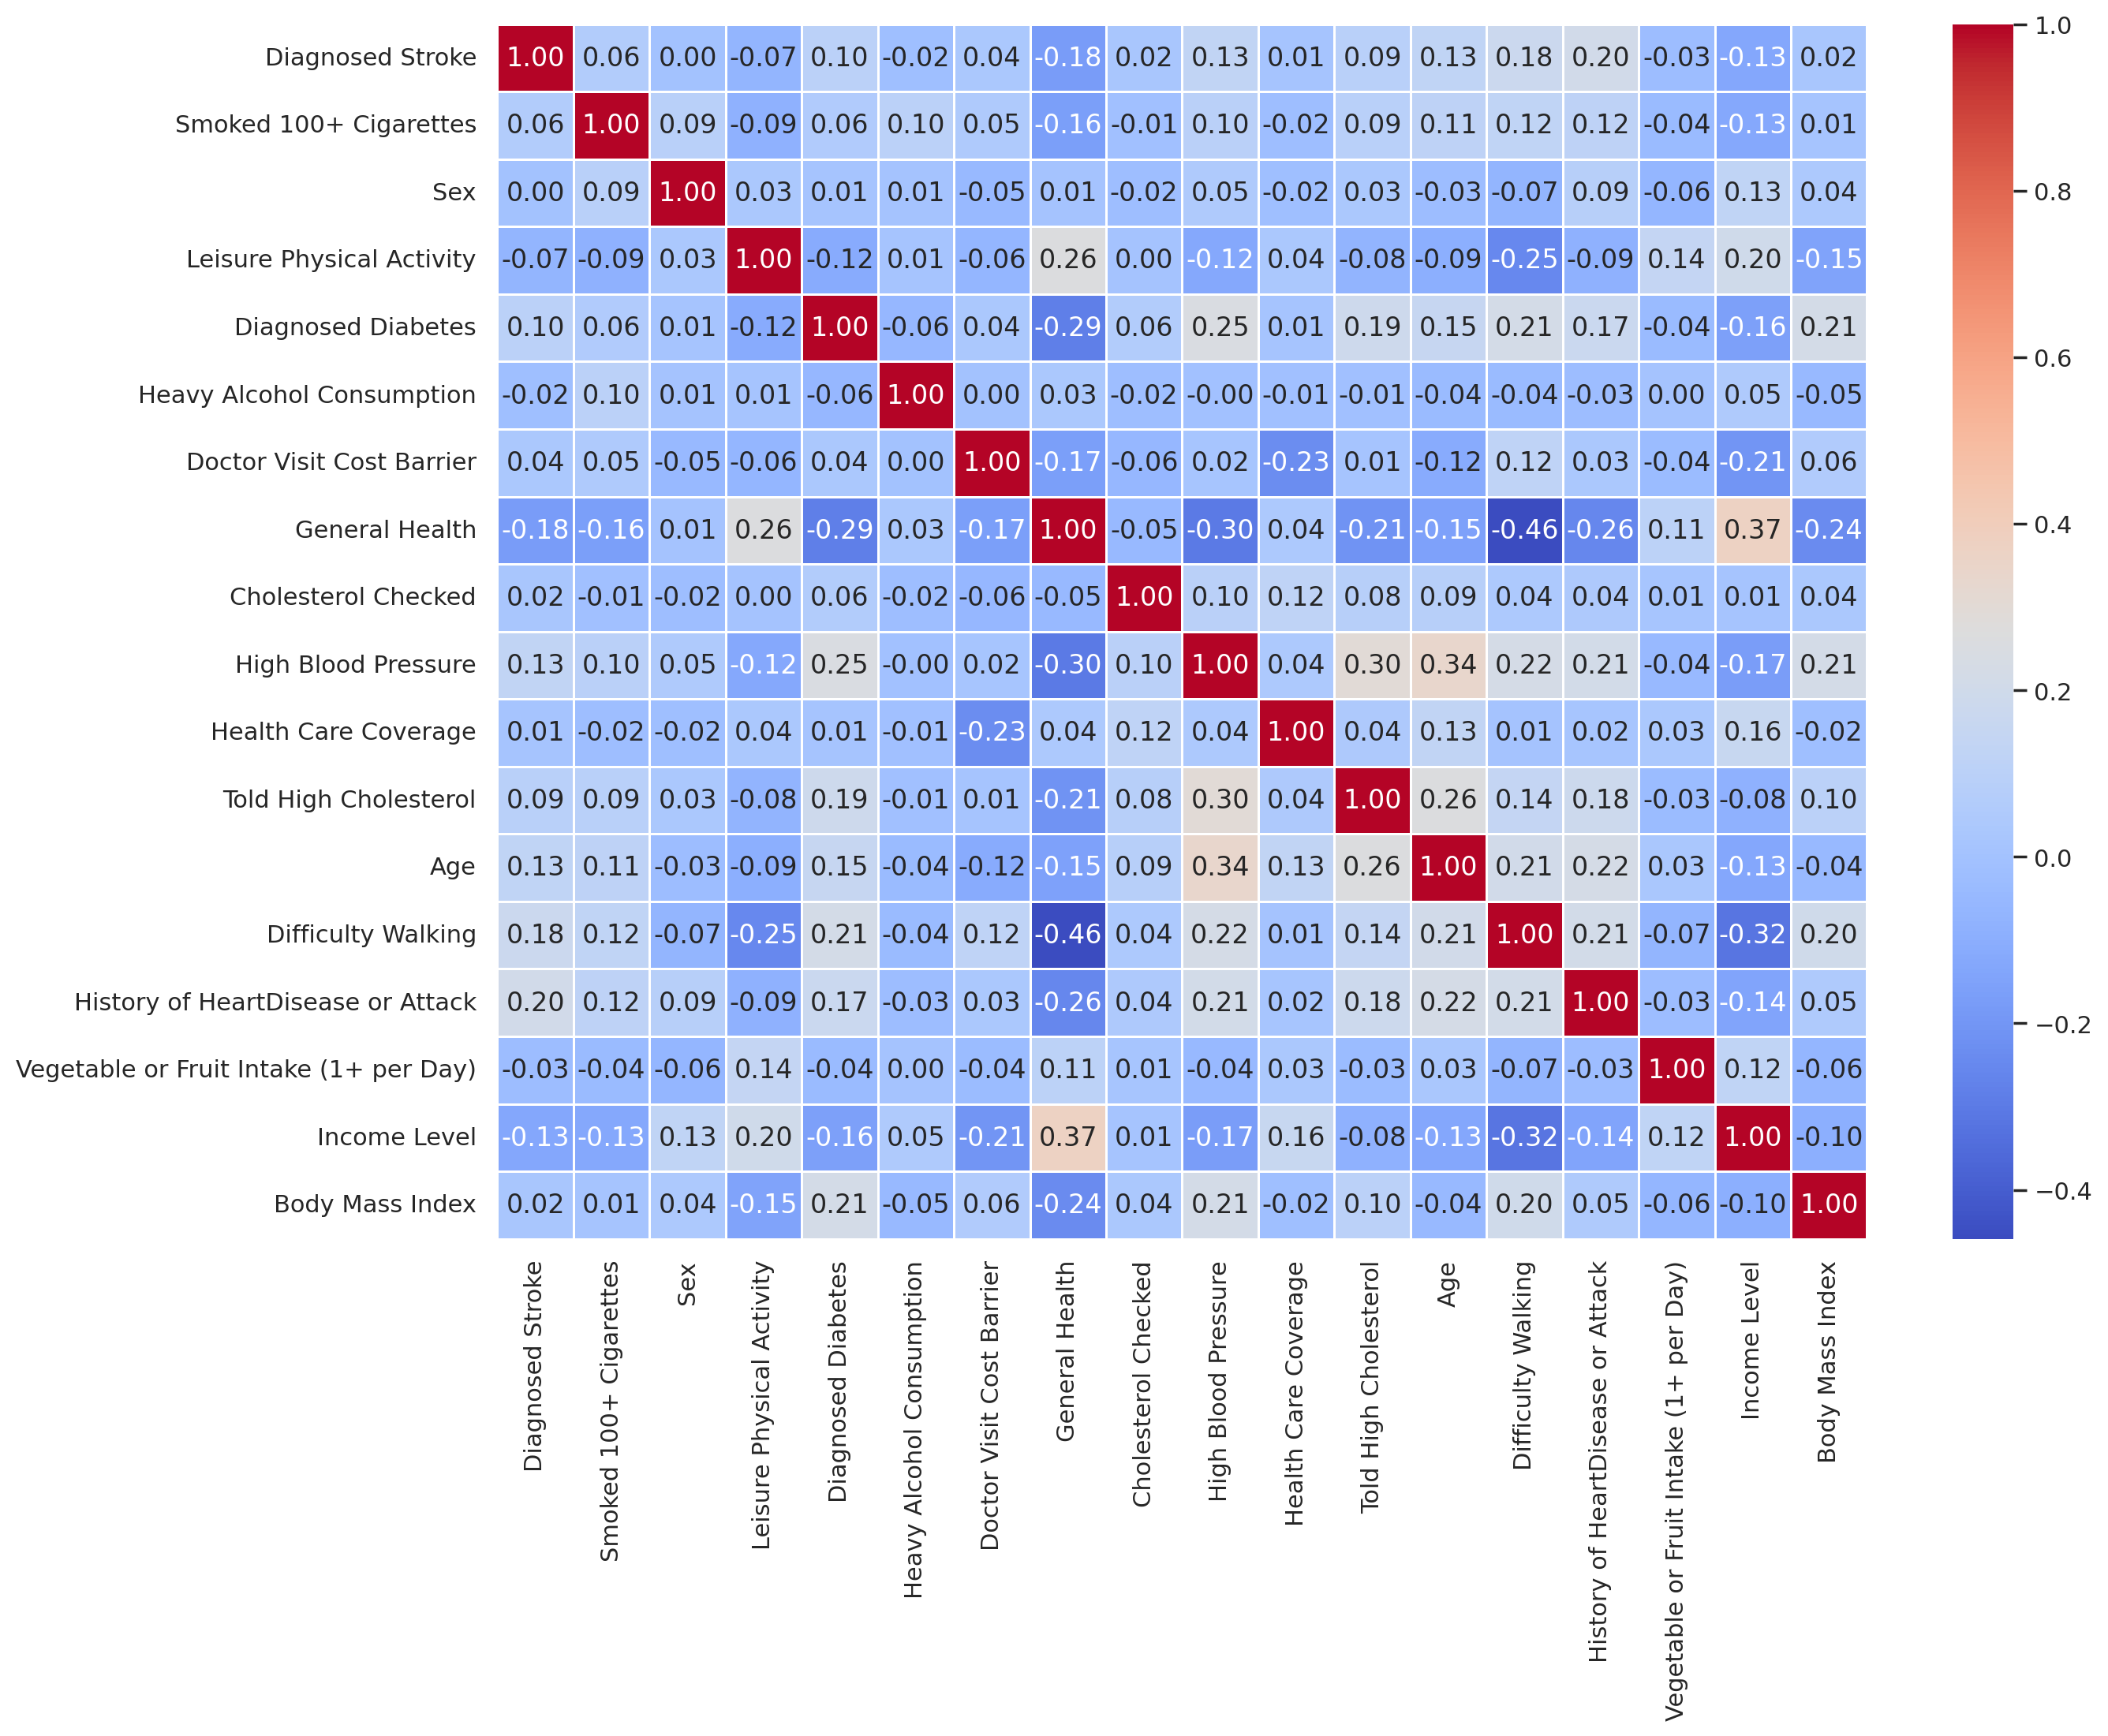

In [32]:
numerical = list(set(train_df)-{'ID'})
corr_matrix = train_df[numerical].corr()
plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix,annot=True,fmt='.2f',cmap='coolwarm',linewidths=.5)

# **Feature Engineering**

In [ ]:
def feature_engineer(df):
    df['mean'] = df[features].mean(axis=1)
    df['max'] = df[features].max(axis=1)
    df['std'] = df[features].std(axis=1)
    df['sum'] = df[features].sum(axis=1)
    df['skew'] = df[features].skew(axis=1)
    df['kurt'] = df[features].kurt(axis=1)

In [ ]:
for df in train_df, test_df:
    feature_engineer(df)
train_df.drop(columns=["id"], inplace=True)
test_df.drop(columns=["id"], inplace=True)

In [ ]:
train_df.head()

# **Modeling**

In [ ]:
features = test_df.columns.values[0:]
X = train_df[features].values
y = train_df['History of HeartDisease or Attack'].values
X_test = test_df[features].values
print(f"Feature columns: {features}")

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain size: {X_train.shape[0]}")
print(f"Validation size: {X_val.shape[0]}")

Preset alias specified: 'best' maps to 'best_quality'.
Verbosity: 2 (Standard Logging)


KeyboardInterrupt: 

In [ ]:
clf = TabPFNClassifier()
clf.fit(X_train, y_train)

# **Evaluation**

In [ ]:
y_val_pred = clf.predict(X_val)
y_val_proba = clf.predict_proba(X_val)
val_accuracy = fbeta_score(y_val, y_val_pred)
print(f"Validation Accuracy: {val_accuracy:.4f}")

In [ ]:
predictions = clf.predict(test_df)
predictions

# **Submission**

In [ ]:
sam_sub = pd.read_csv('sub/sample_submission.csv')
sam_sub

,0,1
0,0.554016,0.445984
1,0.650095,0.349905
2,0.436197,0.563803
3,0.776274,0.223726
4,0.821187,0.178813


In [ ]:
sub = pd.DataFrame({
    'ID' : sam_sub['ID'],
    'History of HeartDisease or Attack' : predictions
})
sub.head()

,0,1,outcome
0,0.554016,0.445984,No
1,0.650095,0.349905,No
2,0.436197,0.563803,Yes
3,0.776274,0.223726,No
4,0.821187,0.178813,No


In [ ]:
sub.to_csv('submission.csv', index=False)

,ID,History of HeartDisease or Attack
0,test_000001,No
1,test_000002,No
2,test_000003,No
3,test_000004,NaN
4,test_000005,NaN
